# 

# Capstone Project: Crop Recommendation Machine Learning Model 

## Overview

Crop Recommendation Machine Learning project aims to develop a machine learning–based system that enables farmers, agricultural stakeholders, and lenders to make more informed decisions related to crop selection and risk management. By leveraging historical production, yield, and irrigation data at the state and county level, the model provides data-driven crop recommendations, reducing reliance on traditional practices, intuition, or incomplete information.

The system is designed to help farmers identify crops with higher suitability and potential yield for their region, thereby minimizing the risk of suboptimal production. At the same time, it provides value to banks and agricultural lenders by offering insights into crop performance patterns, enabling better assessment of lending risk and more informed financial decisions.


### Objective

The objective of this project is to deliver a data-driven capability that identifies and ranks the best-performing crops for a given state and county based on historical yield data. This solution is intended to support farmers, agricultural stakeholders, and agricultural lenders by assisting with information on suitable crops for planting, thereby improving crop selection decisions and regional crop risk assessment.

The project focuses on developing and evaluating machine learning models—including KNN, Logistic Regression, Decision Tree, Random Forest and SVC to predict and recommend crops under different feature engineering strategies. It aims to minimize agricultural risk by helping farmers avoid low-yield crops while also supporting financial institutions in assessing crop viability and lending risk. Additionally, the solution emphasizes real-world applicability by enabling predictions with limited inputs such as state and county and is designed to be scalable for future enhancements with additional agricultural data.

The project follows the CRISP-DM (Cross-Industry Standard Process for Data Mining) framework to ensure a structured and iterative approach, covering business understanding, data preparation, modeling, evaluation, and deployment.


### Understanding Business Data

The primary data source for this project is an agricultural production dataset containing state and county level crop information, including irrigated acreage and yield. The data is obtained from the USDA (United States Department of Agriculture) QuickStats database and is downloaded as a CSV report from https://quickstats.nass.usda.gov/ and converted to excel sheet. This dataset serves as the core data source for model training and evaluation.

### Read in the Data

In [232]:
import pandas as pd
import re
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, accuracy_score, classification_report
from sklearn.metrics import precision_score, recall_score, f1_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import LabelEncoder
import time

In [233]:
crop_details = pd.read_excel("data/crop_details.xlsx")
crop_details.head()

,Program,Year,Period,Week Ending,Geo Level,State,State ANSI,Ag District,Ag District Code,County,...,Zip Code,Region,watershed_code,Watershed,Commodity,Data Item,Domain,Domain Category,Value,CV (%)
0,SURVEY,2024,YEAR,NaN,COUNTY,PENNSYLVANIA,42,NaN,99,OTHER COUNTIES,...,NaN,NaN,0,NaN,CORN,"CORN, GRAIN - YIELD, MEASURED IN BU / ACRE",TOTAL,NOT SPECIFIED,148.3,3.1
1,SURVEY,2024,YEAR,NaN,COUNTY,PENNSYLVANIA,42,NaN,99,OTHER COUNTIES,...,NaN,NaN,0,NaN,CORN,"CORN, SILAGE - YIELD, MEASURED IN TONS / ACRE",TOTAL,NOT SPECIFIED,16.0,2.3
2,SURVEY,2024,YEAR,NaN,COUNTY,PENNSYLVANIA,42,NaN,99,OTHER COUNTIES,...,NaN,NaN,0,NaN,SOYBEANS,"SOYBEANS - YIELD, MEASURED IN BU / ACRE",TOTAL,NOT SPECIFIED,43.6,3.9
3,SURVEY,2024,YEAR,NaN,COUNTY,PENNSYLVANIA,42,CENTRAL,50,BLAIR,...,NaN,NaN,0,NaN,CORN,"CORN, GRAIN - YIELD, MEASURED IN BU / ACRE",TOTAL,NOT SPECIFIED,161.1,3.0
4,SURVEY,2024,YEAR,NaN,COUNTY,PENNSYLVANIA,42,CENTRAL,50,BLAIR,...,NaN,NaN,0,NaN,CORN,"CORN, SILAGE - YIELD, MEASURED IN TONS / ACRE",TOTAL,NOT SPECIFIED,18.0,3.1


In [234]:
# Ensuring all the data is captured with its description easy understand 
crop_details.attrs['Program']= "USDA provide the data as two programs SURVEY and CENSUS, this project chooses information \
collected as part of Survey Program."
crop_details.attrs["Year"] = "Year in which the data was collected."
crop_details.attrs["Period"] = "Reporting period (e.g., YEAR). this project choose to evaluate information collected on yearly basis."
crop_details.attrs["Geo Level"] = "Level at which the geographic detail was collected like STATE or COUNT"
crop_details.attrs["State"] = "Name of the state."
crop_details.attrs["State ANSI"] = "Numeric ANSI/FIPS code for the state."
crop_details.attrs["Ag District"] = "It is a designated geographic area, typically initiated by landowners and certified by \
state/local governments, designed to protect and promote active farming."
crop_details.attrs["Ag District Code"]  = "Code for the agricultural district."
crop_details.attrs["County"] = "Name of the County in a state."
crop_details.attrs["County ANSI"]  = "Numeric ANSI/FIPS code for the county."
crop_details.attrs["Zip Code"] = "ZIP code at county level."
crop_details.attrs["Region"] = "Farm Resource Regions are categorized on shared characteristics rather than rigid state boundaries. \
These regions are derived from cluster analysis of commodities produced, soil, climate, and water." 
crop_details.attrs["watershed_code"] = "Numeric code for watershed area."
crop_details.attrs["Watershed"]  = "It is defined as a specific area of land—ranging from small plots to vast regions—where all water,\
including rain and snowmelt, drains to a common outflow point, such as a creek, river, lake, or reservoir."
crop_details.attrs["Commodity"] = "Type of Crop type."
crop_details.attrs["Data Item"] = "It is a field that provide a combination of crop sub type and yield measured in BU(Bushels) \
or Tonnes per Acre"
crop_details.attrs["Domain"] = "It refers to the sub-classification attribute used to break down or subset a data item, \
such as production, acreage, or yield. With classification of measurement in TOTAL or IRRIGATED.\
This project choose to limit the data attributes for TOTAL based on  yield."
crop_details.attrs["Domain Category"] = "Subcategory of domain is not specified by USDA." 
crop_details.attrs

{'Program': 'USDA provide the data as two programs SURVEY and CENSUS, this project chooses information collected as part of Survey Program.',
 'Year': 'Year in which the data was collected.',
 'Period': 'Reporting period (e.g., YEAR). this project choose to evaluate information collected on yearly basis.',
 'Geo Level': 'Level at which the geographic detail was collected like STATE or COUNT',
 'State': 'Name of the state.',
 'State ANSI': 'Numeric ANSI/FIPS code for the state.',
 'Ag District': 'It is a designated geographic area, typically initiated by landowners and certified by state/local governments, designed to protect and promote active farming.',
 'Ag District Code': 'Code for the agricultural district.',
 'County': 'Name of the County in a state.',
 'County ANSI': 'Numeric ANSI/FIPS code for the county.',
 'Zip Code': 'ZIP code at county level.',
 'Region': 'Farm Resource Regions are categorized on shared characteristics rather than rigid state boundaries. These regions are de

# Data Understanding & Observations
There are a total of 31,770 entries spread across 11 states and 615 counties. The scope of this project has been intentionally limited to these 11 states, with the understanding that the solution can be scaled to include additional states in the future based on scope and business requirements.

## Data Features and Descriptions 
* Program – USDA provide the data as two programs SURVEY and CENSUS, this project chooses information collected as part of Survey Program.
* Year – Year in which the data was collected.
* Period – Reporting period (e.g., YEAR). this project choose to evaluate information collected on yearly basis.
* Geo Level – Level at which the geographic detail was collected like STATE or COUNTY.
* State – Name of the state.
* State ANSI – Numeric ANSI/FIPS code for the state.
* Ag District –  It is a designated geographic area, typically initiated by landowners and certified by state/local governments, designed to protect and promote active farming.
* Ag District Code – Code for the agricultural district.
* County – Name of the County in a state.
* County ANSI – Numeric ANSI/FIPS code for the county.
* Zip Code – ZIP code at county level.
* Region – Farm Resource Regions are categorized on shared characteristics rather than rigid state boundaries. These regions are derived from cluster analysis of commodities produced, soil, climate, and water. 
* watershed_code – Numeric code for watershed area.
* Watershed – It is defined as a specific area of land—ranging from small plots to vast regions—where all water, including rain and snowmelt, drains to a common outflow point, such as a creek, river, lake, or reservoir.
* Commodity – Type of Crop
* Data Item – It is a field that provide a combination of crop sub type and yield measured in BU(Bushels) or Tonnes per Acre 
* Domain – It refers to the sub-classification attribute used to break down or subset a data item , such as production, acreage, or yield. With classification of measurement in TOTAL or IRRIGATED. This project choose to limit the data attributes for TOTAL based on  yield.
* Domain Category – Subcategory of domain is not specified by USDA.

## Observations

* Several data attribues like **Program, Period, Geo Level, watershed_code, Domain and Domain Category** provided by USDA contains constant or non-informative values. Therefore, will not contribute to predictive performance.
    * Program has constant value "SURVEY"
    * Period has constant value "YEAR"
    * Geo Level has constant value "COUNTY"
    * watershed_code has constant value "'00000000"
    * Domain has constant value "TOTAL"
    * Domain Category has constant value "NOT SPECIFIED"

* Data attributes like **Week Ending, Zip Code, Region and Watershed** are empty.

* **Commodity** provides a generic classification of crops but does not capture further details such as specific varieties within the same crop for example **corn, grain vs silage**. The absence of this information may result in farmers, lenders, and other agricultural stakeholders making decisions based on less productive crop options. This limitation can increase lending risk, reduce farm profitability, and lead to higher inventory and operational costs for stakeholders that provide services across the crop production cycle.

* **Data Item** carries a significant amount of information, including sub-categories of crops and the associated yield measurements expressed in different units such as bushels or tonnes. The field by itself is not  useful for analysis and requires additional processing. Decomposing the Data Item into multiple structured features, such as crop sub-category and standardized yield units, enables more meaningful analysis and supports better outcomes for farmers, lenders, and other agricultural stakeholders.

* The **Value** of the crop can be misleading because yield values are represented in different units, such as bushels or tonnes, as indicated in the **Data Item** column. These values must be standardized to a common unit to enable correct prediction based on crop performance.

### Data Preparation

* Data attribues like Program, Period, Geo Level, watershed_code, Domain and Domain Category provided by USDA contains constant or non-informative values. Therefore, will not contribute to predictive performance, hence removing to simplify feature dimesions.
* Data attributes like Week Ending, Zip Code, Region and Watershed are empty, hence removing them to simplify feature dimesions

In [235]:
crop_df = crop_details.copy()
crop_df = crop_df.drop(
    columns=[
        "Program",
        "Period",
        "Geo Level",
        "watershed_code",
        "Domain",
        "Domain Category",
        "Week Ending",
        "Zip Code",
        "Region",
        "Watershed"
    ]
)
crop_df.head()

,Year,State,State ANSI,Ag District,Ag District Code,County,County ANSI,Commodity,Data Item,Value,CV (%)
0,2024,PENNSYLVANIA,42,NaN,99,OTHER COUNTIES,NaN,CORN,"CORN, GRAIN - YIELD, MEASURED IN BU / ACRE",148.3,3.1
1,2024,PENNSYLVANIA,42,NaN,99,OTHER COUNTIES,NaN,CORN,"CORN, SILAGE - YIELD, MEASURED IN TONS / ACRE",16.0,2.3
2,2024,PENNSYLVANIA,42,NaN,99,OTHER COUNTIES,NaN,SOYBEANS,"SOYBEANS - YIELD, MEASURED IN BU / ACRE",43.6,3.9
3,2024,PENNSYLVANIA,42,CENTRAL,50,BLAIR,13.0,CORN,"CORN, GRAIN - YIELD, MEASURED IN BU / ACRE",161.1,3.0
4,2024,PENNSYLVANIA,42,CENTRAL,50,BLAIR,13.0,CORN,"CORN, SILAGE - YIELD, MEASURED IN TONS / ACRE",18.0,3.1


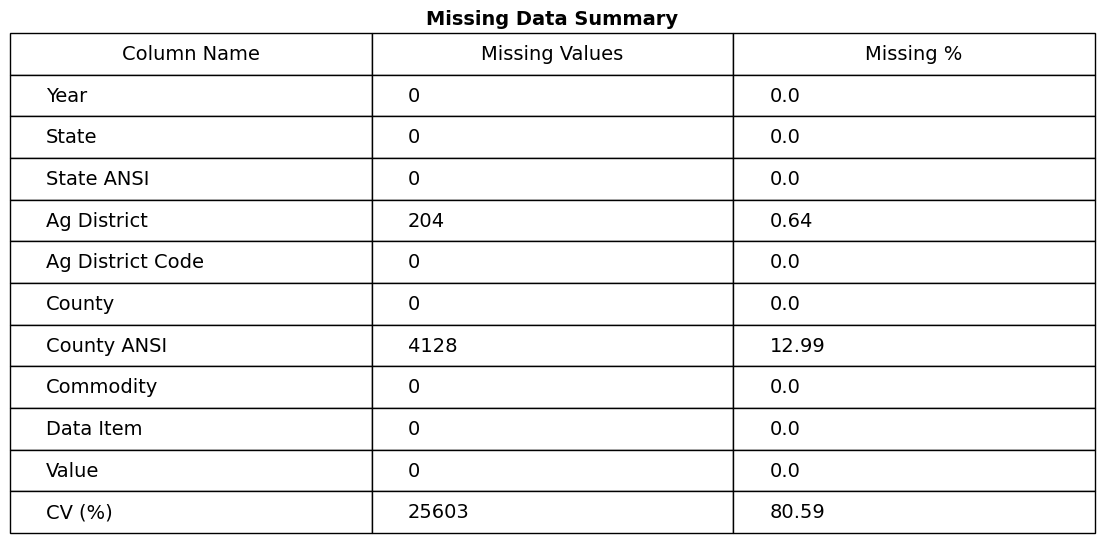

In [236]:

#  Understanding missing data patterns to determine appropriate imputation or removal strategies during data refinement.

crop_df.isna().sum()
missing_table = (
    crop_df.isna()
    .sum()
    .reset_index()
    .rename(columns={
        "index": "Column Name",
        0: "Missing Values"
    })
)
missing_table["Missing %"] = (
    missing_table["Missing Values"] / len(crop_df) * 100
).round(2)


fig, ax = plt.subplots(figsize=(14, 6))
ax.axis('off')
ax.set_title(
    "Missing Data Summary",
    fontsize=14,
    fontweight="bold",
    pad=20
)

table = ax.table(
    cellText=missing_table.values,
    colLabels=missing_table.columns,
    loc='center',
    cellLoc='left'
)

table.set_fontsize(14)
table.scale(1, 2.5)

plt.savefig(
    "images/missing_data_summary.png",
    bbox_inches="tight",
    dpi=300
)
plt.show()

# Missing Data Analysis
* Over 80% of the data is missing in **CV (%)**, which limits its usefulness for analysis and modeling. Given its high level of missingness and secondary relevance to crop prediction, retaining this column does not add meaningful value.
* **Ag District** has 204 missing values. Additionally, Ag District remains consistent for a given combination of State and County and does not provide additional variance beyond what is already captured by State and County. As a result, it is not relevant to the current business requirement.
* **County ANSI** is a coded representation of the County attribute and does not introduce additional dimensional variance compared to the County name itself. Replacing County with County ANSI for modeling purposes would require additional conversion logic between inputs and outputs without offering meaningful predictive benefits. 
* Based on these observations, removing the column **CV (%)** helps reduce dimensionality while retaining the most relevant features that directly impact prediction performance. While removal of columns like **Ag District and County ANSI** will be evaluated based on their on feature importance.

In [237]:
#  Removing column CV (%) as 80% of data is  missing

crop_df = crop_df.drop(
    columns=[
        "CV (%)"
    ]
)
crop_df.isna().sum()


Year                   0
State                  0
State ANSI             0
Ag District          204
Ag District Code       0
County                 0
County ANSI         4128
Commodity              0
Data Item              0
Value                  0
dtype: int64

In [238]:

# Data Clean up - Handling Missing County ANSI Codes
# Missing County ANSI values were replaced using the standard placeholder value 999, 
# which is commonly usedcode  in U.S. data systems to represent unknown or aggregated counties.
# This preserves dataset completeness while avoiding incorrect geographic misclassification.
crop_df["county_missing_flag"] = crop_df["County ANSI"].isna().astype(int)
crop_df["County ANSI"] = crop_df["County ANSI"].fillna(999)
crop_df["County ANSI"].isna().sum()

0

In [239]:

# Data Cleanup – Handling Missing Ag District Values by removing null records

original_records= crop_df.shape[0]
print(f'Size of crop dataset before dropping NaN: {original_records}')
crop_df = crop_df.dropna()
aft_del  = crop_df.shape[0]
print(f'Size of crop dataset after dropping NaN: {aft_del}')
print(f'Percentage of Data Dropped is: {round((((original_records-aft_del)/original_records)*100),2)}')



Size of crop dataset before dropping NaN: 31770
Size of crop dataset after dropping NaN: 31566
Percentage of Data Dropped is: 0.64


**Extraction of Structured Fields from Data Item:** The Data Item field contained multiple pieces of information embedded in text. This field was parsed to extract crop name, sub-category, and measurement unit, allowing these attributes to be represented as structured columns/features suitable for analysis and modeling.


In [240]:

# Extract crop name, sub category, and measurement unit from USDA Data Item field.
def parse_data_item(text):
    if pd.isna(text):
        return (None, None)
        
    # print(text)
    text = str(text)
    
    if " - " in text:
        before, after = text.split(" - ", 1)
        before, after = before.strip(), after.strip()
    else:
        before, after = text.strip(), ""
        
    # print(before, after)    
    if "," in before:
        sub_commodity = before.split(",", 1)[1].strip()
    else:
        sub_commodity =  before.strip()
    
    unit_match = re.search(r"MEASURED IN\s+(.*)", after)
    unit = unit_match.group(1).strip() if unit_match else None

    return pd.Series({"Sub_Commodity": sub_commodity, "Unit": unit})




In [241]:
# Data Conversion
# Create Sub Commodity and Unit of measurement columns
crop_df[["Sub_Commodity", "Unit"]] = crop_df["Data Item"].apply(parse_data_item)
crop_df.head()

,Year,State,State ANSI,Ag District,Ag District Code,County,County ANSI,Commodity,Data Item,Value,county_missing_flag,Sub_Commodity,Unit
3,2024,PENNSYLVANIA,42,CENTRAL,50,BLAIR,13.0,CORN,"CORN, GRAIN - YIELD, MEASURED IN BU / ACRE",161.1,0,GRAIN,BU / ACRE
4,2024,PENNSYLVANIA,42,CENTRAL,50,BLAIR,13.0,CORN,"CORN, SILAGE - YIELD, MEASURED IN TONS / ACRE",18.0,0,SILAGE,TONS / ACRE
5,2024,PENNSYLVANIA,42,CENTRAL,50,BLAIR,13.0,SOYBEANS,"SOYBEANS - YIELD, MEASURED IN BU / ACRE",54.9,0,SOYBEANS,BU / ACRE
6,2024,PENNSYLVANIA,42,CENTRAL,50,CAMBRIA,21.0,CORN,"CORN, GRAIN - YIELD, MEASURED IN BU / ACRE",127.1,0,GRAIN,BU / ACRE
7,2024,PENNSYLVANIA,42,CENTRAL,50,CAMBRIA,21.0,CORN,"CORN, SILAGE - YIELD, MEASURED IN TONS / ACRE",13.0,0,SILAGE,TONS / ACRE


**Standardization of Yield Units:** A yield conversion reference sheet was created through research using crop information available from USDA resources and other agricultural data sources. This reference was used to convert yield measurements reported in bushels per acre (BU/Acre) and tons per acre into a standardized unit of pounds per acre (lbs/acre). Standardizing yield units ensures that crop yields are comparable across different commodities and measurement systems.

In [242]:
yield_conv = pd.read_excel("data/yield_unit_conversion.xlsx")
yield_conv["Sub_Commodity"] = yield_conv["Sub_Commodity"].str.strip()
yield_conv.head()

,Meaurement,Commodity,Sub_Commodity,Conversion to LB,Example
0,BU / ACRE,BARLEY,BARLEY,48,80 bu/acre * 48 = 3840 lbs/acre
1,BU / ACRE,CORN,GRAIN,56,100 bu/acre * 56 = 5600 lbs/acre
2,BU / ACRE,OATS,OATS,32,100 bu/acre * 32 = 3200 lbs/acre
3,BU / ACRE,SORGHUM,GRAIN,56,100 bu/acre * 56 = 5600 lbs/acre
4,BU / ACRE,SOYBEANS,SOYBEANS,60,50 bu/acre * 60 = 3000 lbs/acre


**Standardization of Sub_Commodity Values:** The Sub_Commodity column was standardized by removing identifiers such as “irrigated” and “non-irrigated”. This ensures that the same crop sub-category is consistently represented across records, reducing category fragmentation and improving input quality

In [243]:

crop_df["Sub_Commodity"]= crop_df["Sub_Commodity"].str.replace(", IRRIGATED","")
crop_df["Sub_Commodity"]= crop_df["Sub_Commodity"].str.replace(", NON-IRRIGATED","")
main_sub = set(crop_df["Sub_Commodity"].dropna().unique())
conv_sub = set(yield_conv["Sub_Commodity"].dropna().unique())

# Find missing in conversions
missing_in_conversion = main_sub - conv_sub

print("Sub commodities missing in conversion sheet:")
print(missing_in_conversion)

missing_set = {
    'UPLAND, IRRIGATED', 'WINTER, IRRIGATED', 'GRAIN, IRRIGATED', 
    'AIR-CURED DARK (CLASS 3B)', 'GRAIN, NON-IRRIGATED', 
    'AIR-CURED LIGHT BURLEY (TYPE 31)', 'WINTER, NON-IRRIGATED', 
    'UPLAND, NON-IRRIGATED', 'NON-OIL TYPE', 
    'FIRE-CURED (CLASS 2)', 'OIL TYPE', 'FLUE-CURED (CLASS 1)'
}

filtered = (
    crop_df[
        crop_df["Sub_Commodity"].isin(missing_set)
    ][["Commodity","Sub_Commodity", "Unit"]]
    .drop_duplicates()
    .sort_values("Sub_Commodity")
)

print(filtered)

print("All the Sub commodities that are not mapped are in LB / Acre, which does not need conversion as our standard unit is LBs")

Sub commodities missing in conversion sheet:
{'AIR-CURED DARK (CLASS 3B)', 'NON-OIL TYPE', 'OIL TYPE', 'FIRE-CURED (CLASS 2)', 'AIR-CURED LIGHT BURLEY (TYPE 31)', 'FLUE-CURED (CLASS 1)'}
       Commodity                     Sub_Commodity       Unit
13014    TOBACCO         AIR-CURED DARK (CLASS 3B)  LB / ACRE
8205     TOBACCO  AIR-CURED LIGHT BURLEY (TYPE 31)  LB / ACRE
8402     TOBACCO              FIRE-CURED (CLASS 2)  LB / ACRE
7817     TOBACCO              FLUE-CURED (CLASS 1)  LB / ACRE
7907   SUNFLOWER                      NON-OIL TYPE  LB / ACRE
7904   SUNFLOWER                          OIL TYPE  LB / ACRE
All the Sub commodities that are not mapped are in LB / Acre, which does not need conversion as our standard unit is LBs


## Sub commodities missing in conversion sheet:
* NON-OIL TYPE, FLUE-CURED (CLASS 1), OIL TYPE, AIR-CURED LIGHT BURLEY (TYPE 31), AIR-CURED DARK (CLASS 3B), FIRE-CURED (CLASS 2)
* All the Sub commodities that are not mapped are in LB / Acre, which does not need conversion as our standard unit is LBs

In [244]:


# Data Cleanup – Yield Unit Standardization

# All crop yield measurements were converted to a standardized unit (pounds/lbs per acre).
# After normalization, the original Unit and pre-conversion Value columns were removed.
# Since all yields are now expressed in a consistent unit, retaining the original
# measurement units and raw values is unnecessary for modeling.

def conv_to_lbs(commodity, sub_commodity, unit, value):
    
    # If value is missing, return as is
    if pd.isna(value):
        return value
    
    # Only convert BU / ACRE", TONS / ACRE
    if unit in ["BU / ACRE", "TONS / ACRE"]:
        
        # finding matching conversion metric
        conv_row = yield_conv[
            (yield_conv["Commodity"] == commodity) &
            (yield_conv["Sub_Commodity"] == sub_commodity)
        ]
        
        if not conv_row.empty:
            conv_metric = conv_row["Conversion to LB"].iloc[0]
            return value * conv_metric
        
        else:
            # No conversion mapping found
            return value
    
    else:
        return value


crop_df["std_yield"] = crop_df.apply(
    lambda row: conv_to_lbs(
        row["Commodity"],
        row["Sub_Commodity"],
        row["Unit"],
        row["Value"]
    ),
    axis=1
)


crop_df_clean = crop_df.drop(["Data Item", "Unit", "Value"], axis=1)

crop_df_clean.to_excel('data/crop_clean_data.xlsx')
crop_df_clean.head()

,Year,State,State ANSI,Ag District,Ag District Code,County,County ANSI,Commodity,county_missing_flag,Sub_Commodity,std_yield
3,2024,PENNSYLVANIA,42,CENTRAL,50,BLAIR,13.0,CORN,0,GRAIN,9021.6
4,2024,PENNSYLVANIA,42,CENTRAL,50,BLAIR,13.0,CORN,0,SILAGE,36000.0
5,2024,PENNSYLVANIA,42,CENTRAL,50,BLAIR,13.0,SOYBEANS,0,SOYBEANS,54.9
6,2024,PENNSYLVANIA,42,CENTRAL,50,CAMBRIA,21.0,CORN,0,GRAIN,7117.6
7,2024,PENNSYLVANIA,42,CENTRAL,50,CAMBRIA,21.0,CORN,0,SILAGE,26000.0


### Summary of Data Cleanup and Preparation
* Data attribues like Program, Period, Geo Level, watershed_code, Domain and Domain Category provided by USDA contains constant or non-informative values. Therefore, will not contribute to predictive performance, hence removing to simplify feature dimesions.
* Data attributes like Week Ending, Zip Code, Region and Watershed are empty, hence removing them to simplify feature dimesions
* Removal of CV (%) Column: The CV (%) column was removed because approximately 80% of the values were missing, making it unreliable and not useful for meaningful analysis or modeling.
* Handling Missing County ANSI Codes: Missing values in the County ANSI column were replaced with the placeholder value 999, which is commonly used in U.S. data systems to represent unknown or aggregated counties. This approach preserves dataset completeness while avoiding incorrect misclassification.
* Extraction of Structured Fields from Data Item: The Data Item field contained multiple pieces of information embedded in text. This field was parsed to extract crop name, sub-category, and measurement unit, allowing these attributes to be represented as structured columns/features suitable for analysis and modeling.
* Standardization of Sub_Commodity Values: The Sub_Commodity column was standardized by removing identifiers such as “irrigated” and “non-irrigated”. This ensures that the same crop sub-category is consistently represented across records, reducing category fragmentation and improving input quality.
* Standardization of Yield Units: A yield conversion reference sheet was created through research using crop information available from USDA resources and other agricultural data sources. This reference was used to convert yield measurements reported in bushels per acre (BU/Acre) and tons per acre into a standardized unit of pounds per acre (lbs/acre). Standardizing yield units ensures that crop yields are comparable across different commodities and measurement systems.

# Graphical Representations of Data

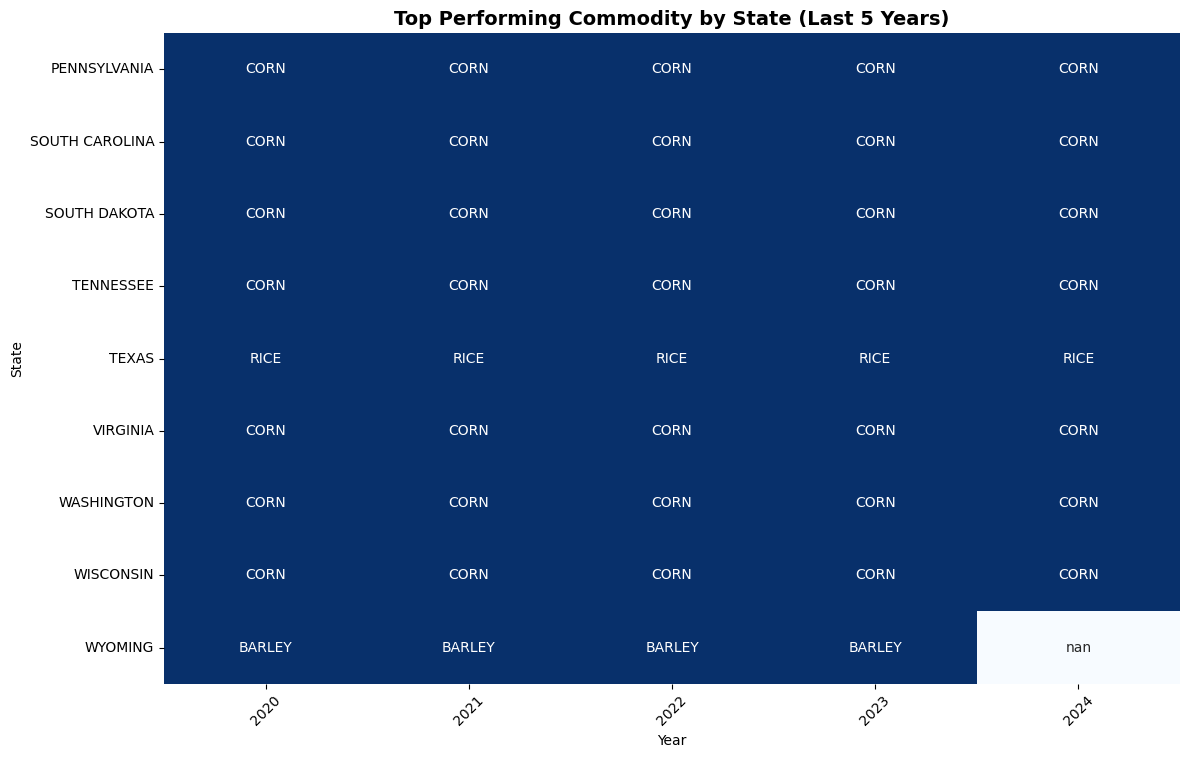

In [245]:
#  Top Performing Commodity by State (Last 5 Years)

# Filter last 5 years
latest_year = crop_df_clean["Year"].max()
last_5 = crop_df_clean[crop_df_clean["Year"] >= latest_year - 4]

#  Aggregate crop yileds by State, Year, Commodity
state_year_agg = (
    last_5
    .groupby(["State", "Year", "Commodity"])["std_yield"]
    .mean()
    .reset_index()
)

#  Get top crop of each state per year
top_by_state_year = (
    state_year_agg
    .sort_values(["State", "Year", "std_yield"], ascending=[True, True, False])
    .groupby(["State", "Year"])
    .first()
    .reset_index()
)

pivot_table = top_by_state_year.pivot(
    index="State",
    columns="Year",
    values="Commodity"
)

plt.figure(figsize=(12, 8))
sns.heatmap(
    pivot_table.notna(),
    annot=pivot_table,
    fmt="",
    cmap="Blues",
    cbar=False
)

plt.title(
    "Top Performing Commodity by State (Last 5 Years)",
    fontsize=14,
    fontweight="bold"
)

plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.savefig("images/top_performing_commodity_state .png", dpi=300,bbox_inches="tight")
plt.show()


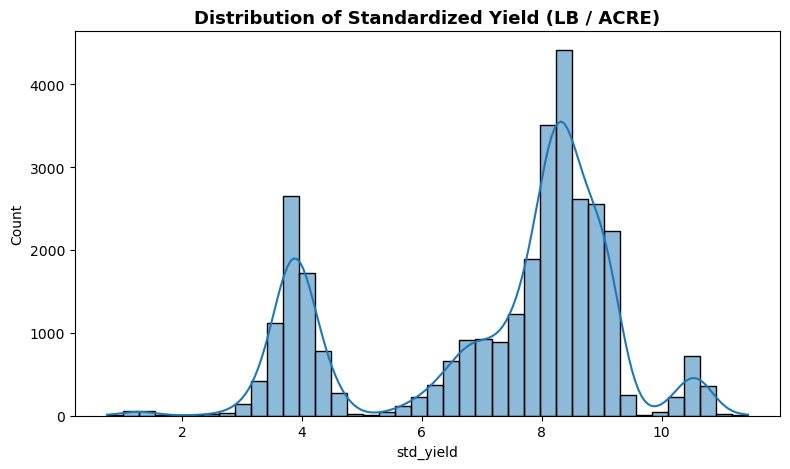

In [246]:
# Distribution of standardized yield
plt.figure(figsize=(8,5))
sns.histplot(np.log1p(crop_df_clean["std_yield"]), bins=40, kde=True)
plt.title("Distribution of Standardized Yield (LB / ACRE)", fontsize=13, fontweight="bold")
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.savefig("images/std_yield_dist.png", dpi=300,bbox_inches="tight")
plt.show()

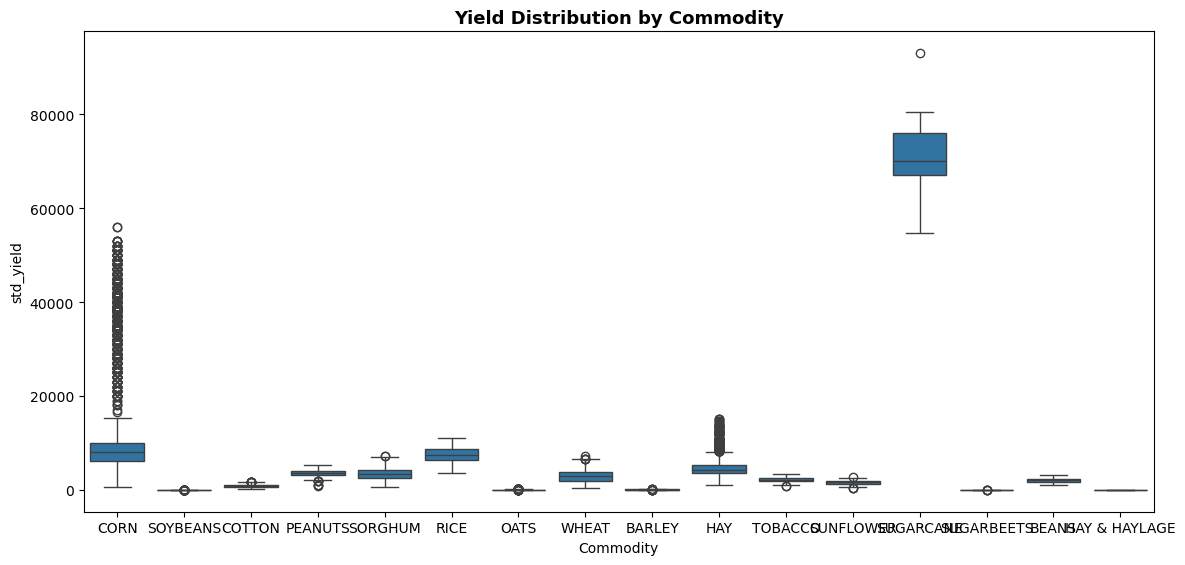

In [247]:
# Yield by Commodity
plt.figure(figsize=(12,6))
sns.boxplot(data=crop_df_clean, x="Commodity", y="std_yield")
plt.title("Yield Distribution by Commodity", fontsize=13, fontweight="bold")
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.savefig("images/yield_by_commodity.png", dpi=300,bbox_inches="tight")
plt.show()

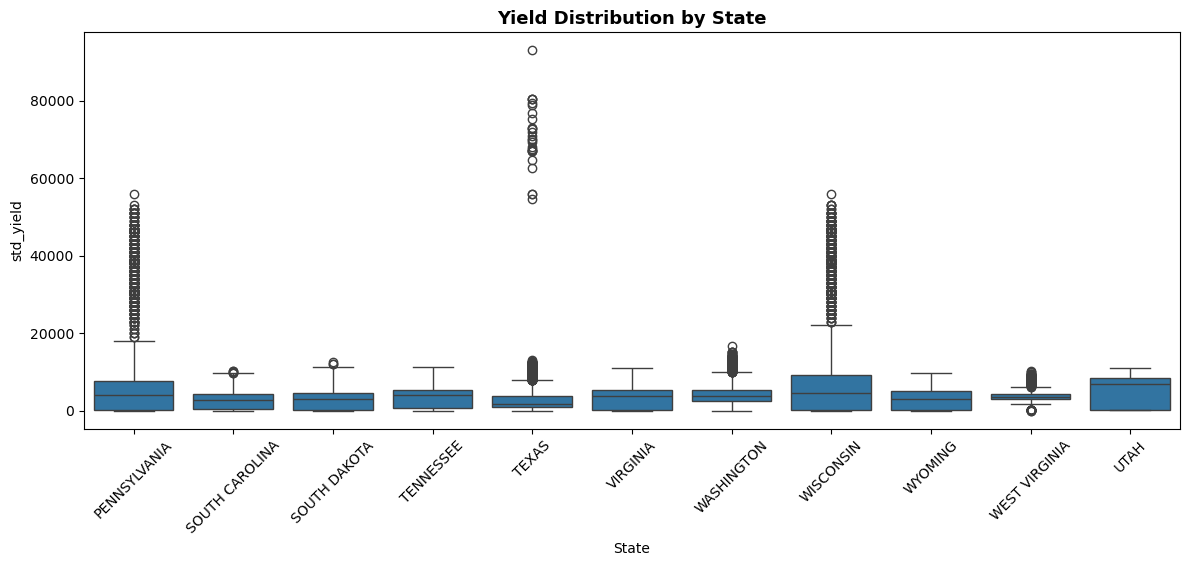

In [248]:
# Yield by State
plt.figure(figsize=(12,6))
sns.boxplot(data=crop_df_clean, x="State", y="std_yield")
plt.xticks(rotation=45)
plt.title("Yield Distribution by State", fontsize=13, fontweight="bold")
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.savefig("images/yield_by_state.png", dpi=300,bbox_inches="tight")
plt.show()

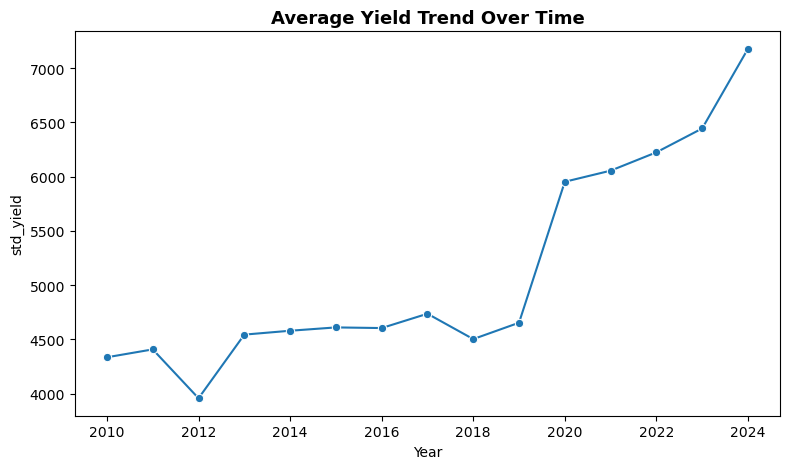

In [249]:
# Time Trend
year_trend = (
    crop_df_clean
    .groupby("Year")["std_yield"]
    .mean()
    .reset_index()
)

plt.figure(figsize=(8,5))
sns.lineplot(data=year_trend, x="Year", y="std_yield", marker="o")
plt.title("Average Yield Trend Over Time", fontsize=13, fontweight="bold")
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.savefig("images/avg_yield_over_time.png", dpi=300,bbox_inches="tight")
plt.show()

# Feature Engineering
The dataset contains both categorical and numeric attributes representing geographic, administrative, and yield related information. To prepare the data for modeling, features were grouped into categorical and numerical variables based on their characteristics and role in prediction.


# Categorical Features
The following fields were treated as categorical variables because they represent geographic or administrative classifications rather than measurable numeric quantities:

    * State – Represents the U.S. state where the crop yield was recorded.
    * Ag District – Agricultural district grouping within a state.
    * County – County level geographic identifier.

# Numeric Features
The following variables were treated as numerical features because they represent quantitative values or encoded identifiers:

    * Year – Indicates the year of the agricultural observation and allows the model to capture trends in crop productivity.
    * State ANSI – Numeric code representing the state. 
    * Ag District Code – Numeric identifier for the agricultural district.
    * County ANSI – Numeric identifier for the county.
    * county_missing_flag – Binary indicator identifying records where the county code was originally missing and replaced with a placeholder.
    * std_yield – Standardized crop yield measured in pounds per acre, representing productivity of the crop.

# Target Variable
New target variable is constructed for following reasons:

    * To create a more precise prediction target, a new variable called target_crop was engineered by combining the Commodity and Sub_Commodity fields.
    * This approach ensures that the model predicts both the main crop category and its specific sub-category, enabling more granular crop recommendations.

In [250]:


#  All fetaures  'Year', 'State', 'State ANSI', 'Ag District', 'Ag District Code',
# 'County', 'County ANSI', 'Commodity', 'county_missing_flag', 'std_yield' are input features
# Except for 'Commodity' and 'Sub_Commodity' which will be predicted from our model


#  Below is the list of categorical and numeric features

cat_feats = [
    "State",
    "Ag District",
    "County"
]

num_feats = [
    "Year",
    "State ANSI",
    "Ag District Code",
    "County ANSI",
    "county_missing_flag",
    "std_yield"
]

In [251]:
#  Separting Features and Target
crop_df_clean["target_crop"] = (
    crop_df_clean["Commodity"].astype(str) + "_" +
    crop_df_clean["Sub_Commodity"].astype(str)
)

X = crop_df_clean[cat_feats + num_feats]
y = crop_df_clean["target_crop"]

lab_enc = LabelEncoder()
y_encoded = lab_enc.fit_transform(y)


### Problem 6: Train/Test Split

The dataset was divided into training and testing subsets to evaluate the performance of the machine learning models on unseen data.
   * A 70%–30% split was used
      * 70% of the data was used for training the model, allowing the algorithm to learn patterns.
      * 30% of the data was reserved as a test dataset to objectively evaluate model performance.

In [252]:

#  Create train and test data sets for inputs and target varibles
# Goal is to divide datasets by 70% for training and 30% for testing
#  Used parameter stratify=y for multi-class balance

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.30,
    random_state=42,
    stratify=y_encoded
)

In [253]:
preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_feats),
        ("num", StandardScaler(), num_feats)
    ]
)


In [259]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(22096, 9)
(9470, 9)
(22096,)
(9470,)


### Baseline Model

Before we build our first model, we want to establish a baseline.  What is the baseline performance that our classifier should aim to beat?

In [260]:
model_comp_other_cols = [
    "Model","Train Time",
    "Pred Time","Accuracy", "Precision",
    "Recall", "F1", "ROC AUC"] 
model_comp_more_metrics = pd.DataFrame(columns=model_comp_other_cols)

def add_mod_metrcis(comp_metrics, model_name, train_time, metrics):
    comp_metrics.loc[len(comp_metrics)]=[
        model_name, 
        train_time, 
        metrics["predict_time"],
        metrics["accuracy"],
        metrics["precision"],
        metrics["recall"],
        metrics["f1"],
        metrics["roc_auc"]
    ]
    return comp_metrics
    

In [261]:
#  This function will calculate accuracy score, precision, recall
#  F1-score and ROC AOC and returns individual scores and dataframe with all scores scores
def get_eval_scores(model, modelname, X, y):
    pred_start_time = time.perf_counter()
    y_pred = model.predict(X)
    pred_end_time = time.perf_counter()
    pred_time = pred_end_time - pred_start_time
    acc_score = accuracy_score(y, y_pred)
    # catching subscribers is the goal, predicting no is not of much business value
    prec_yes = precision_score(y, y_pred, average='weighted', zero_division=0)
    recall_yes = recall_score(y, y_pred, average='weighted')
    f1_yes = f1_score(y, y_pred, average='weighted')
    
    # ROC AUC (only if the model provides probabilities)
    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(X)
        roc_auc = roc_auc_score(y, y_prob, multi_class='ovr', average='weighted')
    else:
        roc_auc = None
    

    # Prepare metrics in DataFrame
    eval_columns = [f"{modelname}(macro)", "Value"]
    baseline_metrcis = pd.DataFrame(columns= eval_columns)
    baseline_metrcis.loc[len(baseline_metrcis)]=["Accuracy", acc_score]
    baseline_metrcis.loc[len(baseline_metrcis)]=["Precision", prec_yes]
    baseline_metrcis.loc[len(baseline_metrcis)]=["Recall", recall_yes]
    baseline_metrcis.loc[len(baseline_metrcis)]=["F1 Score", f1_yes]
    baseline_metrcis.loc[len(baseline_metrcis)]=["ROC AUC", roc_auc]
    # return prec_yes, recall_yes, f1_yes, roc_auc_yes
    return {
        "predict_time": pred_time,
        "accuracy": acc_score,
        "precision": prec_yes,
        "recall": recall_yes,
        "f1": f1_yes,
        "roc_auc": roc_auc,
        "eval metrcis":baseline_metrcis
    }

In [262]:
base_mod_metrics = pd.DataFrame(columns=model_comp_other_cols)
crop_dummy_model = DummyClassifier(
    strategy="stratified",
    random_state=42
)
dummy_train_start_time = time.perf_counter()
crop_dummy_model.fit(X_train, y_train)
dummy_train_end_time = time.perf_counter()
dummy_train_time = dummy_train_end_time - dummy_train_start_time
baseline_metrcis = get_eval_scores(crop_dummy_model, "Dummy Classifier", X_test, y_test)
baseline_metrcis["eval metrcis"]
add_mod_metrcis(base_mod_metrics,"DummyClassifier", dummy_train_time, baseline_metrcis)


,Model,Train Time,Pred Time,Accuracy,Precision,Recall,F1,ROC AUC
0,DummyClassifier,0.002411,0.006357,0.118268,0.118698,0.118268,0.118461,0.500882


### Dummy Classifier Observations
* Correctly predicts about 11–12% of samples
* Macro Precision / Recall / F1 is 0.04 that projects class imbalance, which means rare clases may never get predicted correctly
* ROC AUC is 0.5,  which means no discrimination and behaving correctly on random ranking

The stratified DummyClassifier achieved an accuracy of 11.8% with macro F1 of 0.042, establishing the statistical performance floor. Any model exceeding this baseline demonstrates learned predictive signal beyond random class distribution.

### Simple Model

Use Logistic Regression to build a basic model on your data.  

In [263]:
simp_lgr_pipe =  Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(
        max_iter=3000,
        solver="lbfgs",
        random_state=42
    ))
])

lgr_train_start_time = time.perf_counter()
simp_lgr_pipe.fit(X_train, y_train)
lgr_train_end_time = time.perf_counter()
lgr_train_time = lgr_train_end_time - lgr_train_start_time

simp_lgr_metrics = get_eval_scores(simp_lgr_pipe, "Simple LogReg", X_test, y_test)
add_mod_metrcis(base_mod_metrics,"LogisticRegression", lgr_train_time, simp_lgr_metrics)

,Model,Train Time,Pred Time,Accuracy,Precision,Recall,F1,ROC AUC
0,DummyClassifier,0.002411,0.006357,0.118268,0.118698,0.118268,0.118461,0.500882
1,LogisticRegression,0.941013,0.005981,0.685956,0.675833,0.685956,0.676281,0.965383


## Logistic Regression Observations
* Accuracy (68.6%) is substantially higher than the Dummy baseline (11.8%).
* Precision indicates that more than half of predicted positives are correct.
* Recall demonstrates moderate ability to capture actual positives, suggesting potential improvement through threshold tuning.
* The macro ROC AUC of 0.98 indicates strong class separability and ranking capability.

## Overall Conclusion for Baseline and Simple (Logistic Regression) models

Logistic Regression significantly outperformed the Dummy classifier across all evaluation metrics. With 68.6% accuracy, macro F1 of 0.48, and a macro ROC AUC of 0.98, the model demonstrates strong discriminative ability.

The high ROC AUC suggests the model is well-suited for ranking-based applications such as top-3 crop recommendation, though further  optimization and class-level analysis may improve balanced performance across all crop categories.

# Next Steps
* **Evaluate Multiple Classification Models:** Train and compare several classification algorithms like Logistic Regression, K-Nearest Neighbors (KNN), Decision Tree, Random Forest and Support Vector Classifier (SVC). These models will help determine which algorithm best captures patterns in the agricultural dataset and produces reliable predictions.
* **Hyperparameter Tuning:** For each model will be evaluated by multiple hyperparameter configurations to optimize performance. Parameters such as the number of neighbors in KNN, tree depth in Decision Trees, number of estimators in Random Forest, and kernel parameters in SVC will be tested for best performing model configuration.
* **Ranking-Based Evaluation:** Since the objective of the project is to recommend suitable crops, the models will be evaluated not only on standard classification metrics but also on their ability to correctly rank crop predictions. Metrics such as Top-k accuracy for Top-3 recommendations will be used to measure top predicted options.
* **Feature Evaluation and Selection:** Analyze the contribution of each feature used in the model, including State, Agricultural District, County, Year, geographic codes, and standardized yield. Features will be evaluated to determine their impact on prediction accuracy and ranking performance.
* **Feature Reduction:** Identify features that can be removed without significantly affecting model performance. Eliminating non-informative features can reduce model complexity, improve interpretability, and potentially enhance model generalization.
* **Model Comparison and Selection:** Compare the performance of all trained models using consistent evaluation metrics such as accuracy, precision, recall, F1 score, ROC-AUC, and ranking performance.

**The model that demonstrates the best balance between predictive accuracy and ranking reliability will be selected as the final model for crop recommendation.**

# Model Comparisons


## **Model Execution with Default Behavior:** 
To Evaluate the effectiveness of different classification approaches for crop prediction, five machine learning models were trained and tested: Logistic Regression, K-Nearest Neighbors (KNN), Decision Tree, Support Vector Classifier (SVC) and Random Forest Classifier. Each model was evaluated using metrics such as accuracy, precision, recall, F1 score, ROC AUC, training time and prediction time. This step establishes a baseline to understand how each model performs before applying hyperparameter tuning or feature engineering. It also enables comparison to assess how hyperparameter tuning and feature engineering improve overall model performance.


In [264]:
grid_eval_params = [
    "Model","HyperParams", "Train Time",
    "Pred Time","Accuracy", "Precision",
    "Recall", "F1", "ROC AUC"
] 

gridcv_eval = pd.DataFrame(columns = grid_eval_params)

log_coef_df = pd.DataFrame(columns=["Feature", "Logistic_Importance"])
dt_coef_df = pd.DataFrame(columns=["Feature", "DecisionTree_Importance"])
svc_coef_df = pd.DataFrame(columns=["Feature", "SVC_Importance"])
rf_coef_df = pd.DataFrame(columns=["Feature", "RandomForest_Importance"])

def get_coef_df(pipe, model_name):
    feature_names = (
        pipe.named_steps["preprocessor"]
        .get_feature_names_out()
    )
    
    coefs = pipe.named_steps["model"].coef_[0]
    
    logreg_coef = pd.DataFrame({
        "Feature": feature_names,
        model_name: coefs,
        f"{model_name}_OR": np.exp(coefs)
    })
    logreg_coefs.append(logreg_coef)

In [265]:
simple_class_mod_metrcis = pd.DataFrame(columns=model_comp_other_cols)
gridcv_eval_def_params = pd.DataFrame(columns = grid_eval_params)
models = [
    LogisticRegression(max_iter=2000), 
    KNeighborsClassifier(),
    DecisionTreeClassifier(),
    SVC(probability=False),
    RandomForestClassifier()
]
for model in models:
    pipe = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", model)
    ])
    start_time = time.perf_counter()
    pipe.fit(X_train, y_train)
    end_time = time.perf_counter()
    train_time = end_time - start_time
    model_name = model.__class__.__name__
    # train_acc_score = pipe.score(X_train, y_train)
    metrics= get_eval_scores(pipe, model_name, X_test, y_test)
    gridcv_eval_def_params.loc[len(gridcv_eval_def_params)] = [
            f"{model_name}_{"Default_Params"}",
            "Default Params",
            train_time, 
            metrics["predict_time"],
            metrics["accuracy"],
            metrics["precision"],
            metrics["recall"],
            metrics["f1"],
            metrics["roc_auc"]
    ]
    
# gridcv_eval_def_params  

/var/folders/j9/drwy8ljd6r77zvbqgglkyflr0000gn/T/ipykernel_4932/3330556706.py:29: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  baseline_metrcis.loc[len(baseline_metrcis)]=["ROC AUC", roc_auc]
/var/folders/j9/drwy8ljd6r77zvbqgglkyflr0000gn/T/ipykernel_4932/4157784392.py:22: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  gridcv_eval_def_params.loc[len(gridcv_eval_def_params)] = [


In [266]:
gridcv_eval_def_params_disp = gridcv_eval_def_params.style.set_table_styles([
    {'selector': '', 'props': [('border', '1px solid black')]},
    {'selector': 'td', 'props': [('border', '1px solid black')]},
    {'selector': 'th', 'props': [('border', '1px solid black')]}
])

gridcv_eval_def_params_disp

,Model,HyperParams,Train Time,Pred Time,Accuracy,Precision,Recall,F1,ROC AUC
0,LogisticRegression_Default_Params,Default Params,1.162488,0.011452,0.685956,0.675833,0.685956,0.676281,0.965383
1,KNeighborsClassifier_Default_Params,Default Params,0.011567,4.005966,0.442872,0.436177,0.442872,0.435392,0.850137
2,DecisionTreeClassifier_Default_Params,Default Params,0.183369,0.005395,0.766948,0.765920,0.766948,0.766180,0.869038
3,SVC_Default_Params,Default Params,4.689945,4.621800,0.661985,0.645670,0.661985,0.642634,nan
4,RandomForestClassifier_Default_Params,Default Params,7.449380,0.124757,0.695565,0.694430,0.695565,0.694388,0.944902


## Observations with default parameters
* Decision Tree classifier shows the best overall performance under default parameters, achieving the highest accuracy and F1 score among the evaluated models.It also has very fast training and prediction times, making it both accurate and computationally efficient for this task.
* Logistic Regression and Random Forest exhibit the highest ROC AUC scores, indicating strong capability in distinguishing between crop classes.
* K-Nearest Neighbors performs the weakest, with lower accuracy and significantly higher prediction time due to its distance-based computation.

Overall, Decision Tree provides the best balance of predictive performance and efficiency among the models when using default settings.

## **Hyperparameter Tuning:**
Hyperparameter tuning is used to improve the performance of machine learning models by identifying the optimal configuration of model parameters that control how the algorithm learns from the data. Hyperparameters are set before training and influence aspects such as model complexity, regularization, and decision boundaries. Evaluating multiple hyperparameter combinations helps ensure that the model captures meaningful patterns in the dataset while avoiding underfitting or overfitting.

In this project, hyperparameter tuning was performed using GridSearchCV with cross-validation to systematically test multiple parameter combinations across different classification models.


In [267]:
def eval_logreg(feat_engg, gridcv_eval, preprocessor, X_train, y_train,X_test, y_test):
    logreg_pipe =  Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", LogisticRegression(max_iter=2000))
    ])
    
    param_grid = {
        "model__C": [0.01, 0.1, 1, 10],
        "model__penalty": ["l2"],
        "model__class_weight": [None, "balanced"]
    }
    
    logreg_grid = GridSearchCV(
        logreg_pipe,
        param_grid,
        scoring="accuracy",
        cv=5,
        n_jobs=-1
    )
    logreg_start_time = time.perf_counter()
    logreg_grid.fit(X_train, y_train)
    logreg_end_time = time.perf_counter()
    
    logreg_train_time = logreg_end_time - logreg_start_time
    
    best_model = logreg_grid.best_estimator_
    best_params = logreg_grid.best_params_

    feature_names = best_model.named_steps["preprocessor"].get_feature_names_out()
    log_coef = np.mean(np.abs(best_model.named_steps["model"].coef_), axis=0) 
    log_coef_df_temp = pd.DataFrame({
                        "Feature": feature_names,
                        "Logistic_Importance": log_coef
                    })
    log_coef_df[:]=log_coef_df_temp
      
    model_name = best_model.named_steps["model"].__class__.__name__
    
    logreg_scores =get_eval_scores(best_model, model_name, X_test, y_test)
    
    gridcv_eval.loc[len(gridcv_eval)] = [
            f"{model_name}_{feat_engg}",
            best_params,
            logreg_train_time, 
            logreg_scores["predict_time"],
            logreg_scores["accuracy"],
            logreg_scores["precision"],
            logreg_scores["recall"],
            logreg_scores["f1"],
            logreg_scores["roc_auc"]
    ] 
    
    # print(gridcv_eval)

In [268]:
def eval_knn(feat_engg, gridcv_eval, preprocessor, X_train, y_train,X_test, y_test):
    knn_param_grid = {
        "model__n_neighbors": [5, 7, 11, 15],
        "model__weights": ["uniform", "distance"],
        "model__metric": ["euclidean", "manhattan"]
    }
    
    knn_pipe =  Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", KNeighborsClassifier())
    ])
    
    knn_grid = GridSearchCV(
        knn_pipe,
        knn_param_grid,
        scoring="accuracy",
        cv=5
    )
    
    knn_start_time = time.perf_counter()
    knn_grid.fit(X_train, y_train)
    knn_end_time = time.perf_counter()
    
    knn_train_time = knn_end_time - knn_start_time
    
    best_model = knn_grid.best_estimator_
    best_params = knn_grid.best_params_
    
    model_name = best_model.named_steps["model"].__class__.__name__
    
    knn_scores =get_eval_scores(best_model, model_name, X_test, y_test)
    
    gridcv_eval.loc[len(gridcv_eval)] = [
            f"{model_name}_{feat_engg}",
            best_params,
            knn_train_time, 
            knn_scores["predict_time"],
            knn_scores["accuracy"],
            knn_scores["precision"],
            knn_scores["recall"],
            knn_scores["f1"],
            knn_scores["roc_auc"]
    ]    
    # print(gridcv_eval)



In [269]:
def eval_dt(feat_engg, gridcv_eval, preprocessor, X_train, y_train,X_test, y_test):
    
    dt_pipe = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", DecisionTreeClassifier(random_state=42))
    ])
    
    dt_param_grid = {
        "model__max_depth": [None, 5, 10, 15],
        "model__min_samples_split": [2, 10, 20],
        "model__min_samples_leaf": [1, 5, 10],
        "model__criterion": ["gini", "entropy"],
        "model__class_weight": [None, "balanced"]
    } 
    
    dt_grid = GridSearchCV(
        dt_pipe,
        dt_param_grid,
        scoring="accuracy",
        cv=5,
        n_jobs=-1
    )
    
    dt_start_time = time.perf_counter()
    dt_grid.fit(X_train, y_train)
    dt_end_time = time.perf_counter()
    
    dt_train_time = dt_end_time - dt_start_time
    
    best_model = dt_grid.best_estimator_
    best_params = dt_grid.best_params_

    feature_names = best_model.named_steps["preprocessor"].get_feature_names_out()
    dt_importance = best_model.named_steps["model"].feature_importances_
    dt_coef_df_temp = pd.DataFrame({
                            "Feature": feature_names,
                            "DecisionTree_Importance": dt_importance
                        })    
    dt_coef_df[:]=dt_coef_df_temp
    
    model_name = best_model.named_steps["model"].__class__.__name__
    
    dt_scores =get_eval_scores(best_model, model_name, X_test, y_test)
    
    gridcv_eval.loc[len(gridcv_eval)] = [
            f"{model_name}_{feat_engg}",
            best_params,
            dt_train_time, 
            dt_scores["predict_time"],
            dt_scores["accuracy"],
            dt_scores["precision"],
            dt_scores["recall"],
            dt_scores["f1"],
            dt_scores["roc_auc"]
    ]
    
    # print(gridcv_eval)

In [270]:
def eval_svc(feat_engg, gridcv_eval, preprocessor, X_train, y_train,X_test, y_test):
    svc_param_grid = [
        {
            "model__kernel": ["linear"],
            "model__C": [0.1, 1],
            "model__class_weight": ["balanced"]
        },
        {
            "model__kernel": ["rbf"],
            "model__C": [0.1, 1],
            "model__gamma": ["scale", "auto"],
            "model__class_weight": ["balanced"]
        }
    ]
    
    svc_pipe = Pipeline(steps=[
        ("preprocessor", preprocessor),  
        ("model", SVC(probability=False, random_state=42))
    ])
    
    svc_grid = GridSearchCV(
        svc_pipe,
        svc_param_grid,
        scoring="accuracy",
        cv=3,          
        n_jobs=-1,
        refit=True
    )
    
    svc_start_time = time.perf_counter()
    svc_grid.fit(X_train, y_train)
    svc_end_time = time.perf_counter()
    
    svc_train_time = svc_end_time - svc_start_time
    
    best_model = svc_grid.best_estimator_
    best_params = svc_grid.best_params_

    feature_names = best_model.named_steps["preprocessor"].get_feature_names_out()
    if hasattr(model, "coef_"):
        svc_coef = np.mean(np.abs(model.coef_), axis=0)
    
    elif hasattr(model, "dual_coef_"):
        # fallback importance for non-linear kernels (approximation)
        svc_coef = np.mean(np.abs(model.dual_coef_), axis=0)
        
        # This will NOT match feature count, so skip if mismatch
        if len(svc_coef) != len(feature_names):
            svc_coef = np.zeros(len(feature_names))  # safe fallback
    
    else:
        svc_coef = np.zeros(len(feature_names))  # fallback

    
    # svc_coef = np.mean(np.abs(best_model.named_steps["model"].coef_.toarray()),axis=0)
    svc_coef_df_temp = pd.DataFrame({
                        "Feature": feature_names,
                        "SVC_Importance": svc_coef
                    })
    svc_coef_df[:]=svc_coef_df_temp
     
    model_name = best_model.named_steps["model"].__class__.__name__
    
    svc_scores =get_eval_scores(best_model, model_name, X_test, y_test)    
    
    gridcv_eval.loc[len(gridcv_eval)] = [
            f"{model_name}_{feat_engg}",
            best_params,
            svc_train_time, 
            svc_scores["predict_time"],
            svc_scores["accuracy"],
            svc_scores["precision"],
            svc_scores["recall"],
            svc_scores["f1"],
            svc_scores["roc_auc"]
    ]
    
    # print(gridcv_eval)

In [271]:

def eval_rf(feat_engg, gridcv_eval, preprocessor, X_train, y_train,X_test, y_test):
    
    rf_pipe = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", RandomForestClassifier(random_state=42, n_jobs=-1))
    ])
    
    rf_param_grid = {
        "model__n_estimators": [100, 200],
        "model__max_depth": [None, 10, 20],
        "model__min_samples_split": [2, 10],
        "model__min_samples_leaf": [1, 5]
    } 
    
    rf_grid = GridSearchCV(
        rf_pipe,
        rf_param_grid,
        scoring="accuracy",
        cv=5,
        n_jobs=-1
    )
    
    rf_start_time = time.perf_counter()
    rf_grid.fit(X_train, y_train)
    rf_end_time = time.perf_counter()
    
    rf_train_time = rf_end_time - rf_start_time
    
    best_model = rf_grid.best_estimator_
    best_params = rf_grid.best_params_

    feature_names = best_model.named_steps["preprocessor"].get_feature_names_out()
    rf_importance = best_model.named_steps["model"].feature_importances_
    rf_coef_df_temp = pd.DataFrame({
                        "Feature": feature_names,
                        "RandomForest_Importance": rf_importance
                    })
    rf_coef_df[:]=rf_coef_df_temp    
    
    model_name = best_model.named_steps["model"].__class__.__name__
    
    rf_scores =get_eval_scores(best_model, model_name, X_test, y_test)
    
    gridcv_eval.loc[len(gridcv_eval)] = [
            f"{model_name}_{feat_engg}",
            best_params,
            rf_train_time, 
            rf_scores["predict_time"],
            rf_scores["accuracy"],
            rf_scores["precision"],
            rf_scores["recall"],
            rf_scores["f1"],
            rf_scores["roc_auc"]
    ]
    
    # print(gridcv_eval)

In [272]:
gridcv_eval_hyp_params = pd.DataFrame(columns = grid_eval_params)

In [273]:
eval_logreg("HP", gridcv_eval_hyp_params, preprocessor, X_train, y_train,X_test, y_test)

In [274]:
eval_knn("HP", gridcv_eval_hyp_params, preprocessor, X_train, y_train,X_test, y_test)

In [275]:
eval_dt("HP", gridcv_eval_hyp_params, preprocessor, X_train, y_train,X_test, y_test)

In [276]:
eval_svc("HP", gridcv_eval_hyp_params, preprocessor, X_train, y_train,X_test, y_test)

/var/folders/j9/drwy8ljd6r77zvbqgglkyflr0000gn/T/ipykernel_4932/3330556706.py:29: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  baseline_metrcis.loc[len(baseline_metrcis)]=["ROC AUC", roc_auc]
/var/folders/j9/drwy8ljd6r77zvbqgglkyflr0000gn/T/ipykernel_4932/2378744797.py:66: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  gridcv_eval.loc[len(gridcv_eval)] = [


In [277]:
eval_rf("HP", gridcv_eval_hyp_params, preprocessor, X_train, y_train,X_test, y_test)

/opt/anaconda3/lib/python3.12/site-packages/joblib/externals/loky/process_executor.py:752: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


In [278]:
gridcv_eval_hyp_params_disp = gridcv_eval_hyp_params.style.set_table_styles([
    {'selector': '', 'props': [('border', '1px solid black')]},
    {'selector': 'td', 'props': [('border', '1px solid black')]},
    {'selector': 'th', 'props': [('border', '1px solid black')]}
])

gridcv_eval_hyp_params_disp

,Model,HyperParams,Train Time,Pred Time,Accuracy,Precision,Recall,F1,ROC AUC
0,LogisticRegression_HP,"{'model__C': 10, 'model__class_weight': None, 'model__penalty': 'l2'}",6.966395,0.007898,0.707814,0.700815,0.707814,0.702037,0.969112
1,KNeighborsClassifier_HP,"{'model__metric': 'manhattan', 'model__n_neighbors': 5, 'model__weights': 'uniform'}",62.960448,0.352505,0.488701,0.482036,0.488701,0.480708,0.860246
2,DecisionTreeClassifier_HP,"{'model__class_weight': None, 'model__criterion': 'gini', 'model__max_depth': None, 'model__min_samples_leaf': 5, 'model__min_samples_split': 20}",5.307396,0.005684,0.771383,0.769805,0.771383,0.769631,0.952846
3,SVC_HP,"{'model__C': 1, 'model__class_weight': 'balanced', 'model__kernel': 'linear'}",25.233996,4.059224,0.645090,0.747797,0.645090,0.658698,nan
4,RandomForestClassifier_HP,"{'model__max_depth': None, 'model__min_samples_leaf': 1, 'model__min_samples_split': 10, 'model__n_estimators': 200}",24.854831,0.043056,0.717107,0.712443,0.717107,0.713119,0.958386


## Hyperparameter Tuning observations:
* The Decision Tree classifier continues to show the strongest overall performance after hyperparameter tuning, achieving the highest accuracy and F1 score among the evaluated models.
* The ROC AUC score of the Decision Tree classifier is also comparable to the strong ROC AUC performance of Logistic Regression and Random Forest classifiers, indicating good class separation capability.
* SVC demonstrates moderate performance, while K-Nearest Neighbors remains the weakest performer among the evaluated models.

## Engineering features

### Modeling with Hyperparameters and Feature Engineering 1 (HP_FE1)

* **Ag District**: This feature was removed because agricultural districts are aggregations of counties and therefore do not provide additional information beyond the county-level geographic feature already present in the dataset. Removing it reduces redundancy while preserving relevant geographic information.

* **State ANSI and County ANSI**: These numerical identifiers were removed because the same geographic information is already represented through the categorical State and County features. Keeping both forms would introduce redundant information without improving model learning.

* **std_yield**: This feature was removed because yield values are typically known only after crop production and may introduce potential data leakage when predicting crop suitability. The aggregated historical yield features were created instead to represent long-term productivity patterns without relying on outcome-based information.
    * **state_crop_avg_yield:** Historical average crop yield at the state level used to capture long-term regional productivity patterns and reduce yearly fluctuations.
    * **county_crop_avg_yield:** Historical average crop yield at the county level used to capture localized agricultural productivity and improve learning of crop suitability at a finer geographic level.




In [279]:


# Averaging crop yield at state and county level to reduce yearly fluctuations and improve modern learning at geographical level
crop_df_clean["state_crop_avg_yield"] = (
    crop_df_clean.groupby(["State","Commodity"])["std_yield"]
    .transform("mean")
)

crop_df_clean["county_avg_yield"] = (
    crop_df_clean.groupby("County")["std_yield"]
    .transform("mean")
)

#  Dropping columns as Ag District  is redundant with county information, State ANSI is represented as state categorical
#  column, County ANSI is redundant as its represented as County categorical column and std_yield
crop_df_clean = crop_df_clean.drop(columns=["Ag District", "std_yield", "State ANSI", "County ANSI"])

cat_feats_FE1 = [
    "State",
    "County"
]

num_feats_FE1 = [
    "Year",
    "county_missing_flag",
    "state_crop_avg_yield", 
    "county_avg_yield"
]


X_FE1 = crop_df_clean[cat_feats_FE1 + num_feats_FE1]


X_train, X_test, y_train, y_test = train_test_split(
    X_FE1,
    y_encoded,
    test_size=0.30,
    random_state=42,
    stratify=y_encoded
)

preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_feats_FE1),
        ("num", StandardScaler(), num_feats_FE1)
    ]
)


In [280]:
gridcv_eval_hp_fe1 = pd.DataFrame(columns = grid_eval_params)

In [281]:
eval_logreg("HP_FE1", gridcv_eval_hp_fe1, preprocessor, X_train, y_train,X_test, y_test)

In [282]:
eval_knn("HP_FE1", gridcv_eval_hp_fe1, preprocessor, X_train, y_train,X_test, y_test)

In [283]:
eval_dt("HP_FE1", gridcv_eval_hp_fe1, preprocessor, X_train, y_train,X_test, y_test)

In [284]:
eval_svc("HP_FE1", gridcv_eval_hp_fe1, preprocessor, X_train, y_train,X_test, y_test)

/var/folders/j9/drwy8ljd6r77zvbqgglkyflr0000gn/T/ipykernel_4932/3330556706.py:29: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  baseline_metrcis.loc[len(baseline_metrcis)]=["ROC AUC", roc_auc]
/var/folders/j9/drwy8ljd6r77zvbqgglkyflr0000gn/T/ipykernel_4932/2378744797.py:66: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  gridcv_eval.loc[len(gridcv_eval)] = [


In [285]:
eval_rf("HP_FE1", gridcv_eval_hp_fe1, preprocessor, X_train, y_train,X_test, y_test)

/opt/anaconda3/lib/python3.12/site-packages/joblib/externals/loky/process_executor.py:752: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


In [286]:
gridcv_eval_hp_fe1_disp = gridcv_eval_hp_fe1.style.set_table_styles([
    {'selector': '', 'props': [('border', '1px solid black')]},
    {'selector': 'td', 'props': [('border', '1px solid black')]},
    {'selector': 'th', 'props': [('border', '1px solid black')]}
])

gridcv_eval_hp_fe1_disp

,Model,HyperParams,Train Time,Pred Time,Accuracy,Precision,Recall,F1,ROC AUC
0,LogisticRegression_HP_FE1,"{'model__C': 10, 'model__class_weight': None, 'model__penalty': 'l2'}",5.271522,0.004705,0.783844,0.772725,0.783844,0.775174,0.987539
1,KNeighborsClassifier_HP_FE1,"{'model__metric': 'manhattan', 'model__n_neighbors': 15, 'model__weights': 'distance'}",55.651719,0.335753,0.571172,0.571890,0.571172,0.570295,0.870218
2,DecisionTreeClassifier_HP_FE1,"{'model__class_weight': None, 'model__criterion': 'entropy', 'model__max_depth': 10, 'model__min_samples_leaf': 5, 'model__min_samples_split': 20}",2.593039,0.004675,0.887117,0.872098,0.887117,0.865506,0.993295
3,SVC_HP_FE1,"{'model__C': 1, 'model__class_weight': 'balanced', 'model__kernel': 'linear'}",17.759492,3.415014,0.742661,0.850321,0.742661,0.761768,nan
4,RandomForestClassifier_HP_FE1,"{'model__max_depth': None, 'model__min_samples_leaf': 1, 'model__min_samples_split': 10, 'model__n_estimators': 200}",16.365185,0.043549,0.830201,0.825291,0.830201,0.827101,0.989152



## Observations on models with Hyperparameters and Feature Engineering 1 (HP_FE1)
* Decision Tree classifier achieves the best overall performance, achieving the highest accuracy(0.887), precision(0,872), recall(0.887), F1(0.865) and ROC AUC(0.993) score among all evaluated models, indicating strong predictive capability and good class separation capability.
* Decision Tree classifier also maintains very low training and prediction times, making it both accurate and computationally efficient compared to other models.
* Random Forest shows strong performance as well, with high accuracy (~0.83) and a strong ROC AUC score, indicating good class discrimination capability.
* Logistic Regression demonstrates balanced performance, with good ROC AUC and moderate improvements in accuracy after feature engineering.
* SVC accuracy aas increased measurably still showing moderate performance with reasonable precision, higher training and prediction times as compared to other models.
* K-Nearest Neighbors accuracy has increased but remains the weakest performer, with lower accuracy and significantly higher prediction time.

## Model with Hyperparameters and Feature Engineering 2 (FE2)

Feature Engineering 2 (FE2) introduced additional features to better capture geographic specificity and temporal trends in the agricultural data. These transformations help the model learn regional crop patterns and long-term agricultural changes more effectively. The following features were created to evaluate whether these transformations improve model accuracy and other evaluation metrics.

* **state_county:** A combined geographic feature created by concatenating State and County to represent a unique location identifier, enabling the model to learn more precise regional crop suitability patterns.
* **years_from_start:** A temporal feature derived from the Year variable representing the number of years since the earliest observation in the dataset, allowing the model to capture long-term agricultural trends without relying on raw year values.



In [287]:
# Instead of treating State and County separately, create a combined location feature.

crop_df_clean["state_county"] = (
    crop_df_clean["State"].astype(str) + "_" +
    crop_df_clean["County"].astype(str)
)

crop_df_clean["years_from_start"] = (
    crop_df_clean["Year"] - crop_df_clean["Year"].min()
)

cat_feats_FE2 = [
    "state_county"
]

num_feats_FE2 = [
    "years_from_start",
    "county_missing_flag",
    "state_crop_avg_yield",
    "county_avg_yield"
]


X_FE2 = crop_df_clean[cat_feats_FE2 + num_feats_FE2]


X_train, X_test, y_train, y_test = train_test_split(
    X_FE2,
    y_encoded,
    test_size=0.30,
    random_state=42,
    stratify=y_encoded
)

preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_feats_FE2),
        ("num", StandardScaler(), num_feats_FE2)
    ]
)



In [288]:
gridcv_eval_hp_fe2 = pd.DataFrame(columns = grid_eval_params)

In [289]:
eval_logreg("HP_FE2", gridcv_eval_hp_fe2, preprocessor, X_train, y_train,X_test, y_test)

/var/folders/j9/drwy8ljd6r77zvbqgglkyflr0000gn/T/ipykernel_4932/842831966.py:35: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '0       0.301127
1       0.151859
2       0.674523
3       0.482564
4       0.611536
         ...    
760     0.261965
761     0.409409
762     0.374421
763    25.419967
764     1.506965
Name: Logistic_Importance, Length: 765, dtype: float64' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  log_coef_df[:]=log_coef_df_temp


In [290]:
eval_knn("HP_FE2", gridcv_eval_hp_fe2, preprocessor, X_train, y_train,X_test, y_test)

In [291]:
eval_dt("HP_FE2", gridcv_eval_hp_fe2, preprocessor, X_train, y_train,X_test, y_test)

/var/folders/j9/drwy8ljd6r77zvbqgglkyflr0000gn/T/ipykernel_4932/1533558981.py:39: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '0      0.000000
1      0.000000
2      0.000000
3      0.000000
4      0.000000
         ...   
760    0.000000
761    0.002069
762    0.000663
763    0.979681
764    0.010743
Name: DecisionTree_Importance, Length: 765, dtype: float64' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  dt_coef_df[:]=dt_coef_df_temp


In [292]:
eval_svc("HP_FE2", gridcv_eval_hp_fe2, preprocessor, X_train, y_train,X_test, y_test)

/var/folders/j9/drwy8ljd6r77zvbqgglkyflr0000gn/T/ipykernel_4932/2378744797.py:60: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '0      0.0
1      0.0
2      0.0
3      0.0
4      0.0
      ... 
760    0.0
761    0.0
762    0.0
763    0.0
764    0.0
Name: SVC_Importance, Length: 765, dtype: float64' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  svc_coef_df[:]=svc_coef_df_temp
/var/folders/j9/drwy8ljd6r77zvbqgglkyflr0000gn/T/ipykernel_4932/3330556706.py:29: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  baseline_metrcis.loc[len(baseline_metrcis)]=["ROC AUC", roc_auc]
/var/folders/j9/drwy8ljd6r77zvbqgglkyflr0000gn/T/ipykernel_493

In [293]:
eval_rf("HP_FE2", gridcv_eval_hp_fe2, preprocessor, X_train, y_train,X_test, y_test)

/opt/anaconda3/lib/python3.12/site-packages/joblib/externals/loky/process_executor.py:752: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(
/var/folders/j9/drwy8ljd6r77zvbqgglkyflr0000gn/T/ipykernel_4932/762208382.py:38: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '0      0.000258
1      0.000242
2      0.000422
3      0.000307
4      0.000486
         ...   
760    0.000203
761    0.042150
762    0.001799
763    0.650311
764    0.057376
Name: RandomForest_Importance, Length: 765, dtype: float64' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  rf_coef_df[:]=rf_coef_df_temp


In [294]:
gridcv_eval_hp_fe2_disp = gridcv_eval_hp_fe2.style.set_table_styles([
    {'selector': '', 'props': [('border', '1px solid black')]},
    {'selector': 'td', 'props': [('border', '1px solid black')]},
    {'selector': 'th', 'props': [('border', '1px solid black')]}
])

gridcv_eval_hp_fe2_disp

,Model,HyperParams,Train Time,Pred Time,Accuracy,Precision,Recall,F1,ROC AUC
0,LogisticRegression_HP_FE2,"{'model__C': 10, 'model__class_weight': None, 'model__penalty': 'l2'}",5.454009,0.011867,0.781837,0.768993,0.781837,0.771775,0.986596
1,KNeighborsClassifier_HP_FE2,"{'model__metric': 'manhattan', 'model__n_neighbors': 15, 'model__weights': 'distance'}",48.494579,0.305706,0.569588,0.569350,0.569588,0.568223,0.868927
2,DecisionTreeClassifier_HP_FE2,"{'model__class_weight': None, 'model__criterion': 'gini', 'model__max_depth': 10, 'model__min_samples_leaf': 1, 'model__min_samples_split': 20}",2.773443,0.004289,0.880042,0.858968,0.880042,0.868322,0.992374
3,SVC_HP_FE2,"{'model__C': 1, 'model__class_weight': 'balanced', 'model__kernel': 'linear'}",17.443916,3.792758,0.714467,0.820942,0.714467,0.737646,nan
4,RandomForestClassifier_HP_FE2,"{'model__max_depth': None, 'model__min_samples_leaf': 1, 'model__min_samples_split': 10, 'model__n_estimators': 200}",17.581089,0.054174,0.833791,0.825641,0.833791,0.828625,0.990546


## Observations on models with Hyperparameters and Feature Engineering 2 (HP_FE2)
**Feature Engneering 2(HP_FE2)** transformations generated almost comparable results to **Feature Engineering 1 (HP_FE2)** transformations, but the metrics decreased negligeably.
* Decision Tree classifier still continues to deliver the strongest overall performance, achieving the highest accuracy, precision, recall, F1 and ROC AUC score among all evaluated models.
* Random Forest classifier shows the second-best performance, with strong accuracy and balanced precision–recall values, along with a high ROC AUC score.
* Logistic Regression maintains stable performance, with competitive ROC AUC while maintaining moderate accuracy and F1 score.
* K-Nearest Neighbors remains the weakest performer, with significantly lower accuracy, precision, recall, and F1 score.


## Hyperparameters and Feature Engineering 3 (HP_FE3)
* In this setup, the model uses State and County as the only input features to predict the most suitable crop. These features are treated as categorical variables and encoded using one-hot encoding to enable their use in machine learning models.
* This approach removes all engineered and yield-based features to eliminate data leakage and ensure that the model relies solely on information that would realistically be available to farmers and stakeholders.


In [295]:
cat_feats_FE3 = ["State", "County"]

X_FE3 = crop_df_clean[cat_feats_FE3]

X_train, X_test, y_train, y_test = train_test_split(
    X_FE3,
    y_encoded,
    test_size=0.30,
    random_state=42,
    stratify=y_encoded
)

preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_feats_FE3)
    ]
)

gridcv_eval_hp_fe3 = pd.DataFrame(columns = grid_eval_params)
eval_logreg("HP_FE3", gridcv_eval_hp_fe3, preprocessor, X_train, y_train,X_test, y_test)
eval_knn("HP_FE3", gridcv_eval_hp_fe3, preprocessor, X_train, y_train,X_test, y_test)
eval_dt("HP_FE3", gridcv_eval_hp_fe3, preprocessor, X_train, y_train,X_test, y_test)
eval_svc("HP_FE3", gridcv_eval_hp_fe3, preprocessor, X_train, y_train,X_test, y_test)
eval_rf("HP_FE3", gridcv_eval_hp_fe3, preprocessor, X_train, y_train,X_test, y_test)
gridcv_eval_hp_fe3_disp = gridcv_eval_hp_fe3.style.set_table_styles([
    {'selector': '', 'props': [('border', '1px solid black')]},
    {'selector': 'td', 'props': [('border', '1px solid black')]},
    {'selector': 'th', 'props': [('border', '1px solid black')]}
])

gridcv_eval_hp_fe3_disp

/var/folders/j9/drwy8ljd6r77zvbqgglkyflr0000gn/T/ipykernel_4932/842831966.py:35: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '0      0.691992
1      0.638366
2      0.734661
3      0.756595
4      1.135960
         ...   
615    0.090189
616    0.055453
617    0.048915
618    0.030492
619    0.067566
Name: Logistic_Importance, Length: 620, dtype: float64' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  log_coef_df[:]=log_coef_df_temp
/var/folders/j9/drwy8ljd6r77zvbqgglkyflr0000gn/T/ipykernel_4932/1533558981.py:39: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '0      0.010478
1      0.062864
2      0.047877
3      0.067339
4      0.278942
         ...   
615    0.001470
616    0.000487
617    0.000627
618    0.000163
619    0.000626
Name: DecisionTree_Importance, Length: 620, dtype: float64' has dtype 

,Model,HyperParams,Train Time,Pred Time,Accuracy,Precision,Recall,F1,ROC AUC
0,LogisticRegression_HP_FE3,"{'model__C': 0.1, 'model__class_weight': None, 'model__penalty': 'l2'}",2.207512,0.008717,0.264520,0.260927,0.264520,0.241671,0.762196
1,KNeighborsClassifier_HP_FE3,"{'model__metric': 'manhattan', 'model__n_neighbors': 11, 'model__weights': 'distance'}",21.363508,0.233621,0.262408,0.262006,0.262408,0.253390,0.725533
2,DecisionTreeClassifier_HP_FE3,"{'model__class_weight': None, 'model__criterion': 'entropy', 'model__max_depth': None, 'model__min_samples_leaf': 1, 'model__min_samples_split': 2}",1.248277,0.003766,0.258395,0.273167,0.258395,0.250156,0.769642
3,SVC_HP_FE3,"{'model__C': 1, 'model__class_weight': 'balanced', 'model__kernel': 'linear'}",23.624512,4.687376,0.191341,0.463479,0.191341,0.176613,nan
4,RandomForestClassifier_HP_FE3,"{'model__max_depth': 20, 'model__min_samples_leaf': 1, 'model__min_samples_split': 2, 'model__n_estimators': 200}",9.726886,0.028567,0.276874,0.254101,0.276874,0.211087,0.766634


## Observations on models with Hyperparameters and Feature Engineering 1 (HP_FE3)
* Model performance is significantly lower compared to FE1, with accuracy ranging roughly between 19%–28%, indicating limited predictive capability.
* Geographic features State and County alone are insufficient to capture crop suitability, as they do not include critical factors like yield into the mix.
* Overall, HP_FE3 demonstrates the trade-off between real-world applicability and model accuracy, emphasizing the need for richer feature sets to improve prediction quality.


# Visulaizations of results

In [304]:
comb_results = pd.concat([
                gridcv_eval_def_params,
                gridcv_eval_hyp_params,
                gridcv_eval_hp_fe1,
                gridcv_eval_hp_fe2,
                gridcv_eval_hp_fe3
            ], ignore_index=True)


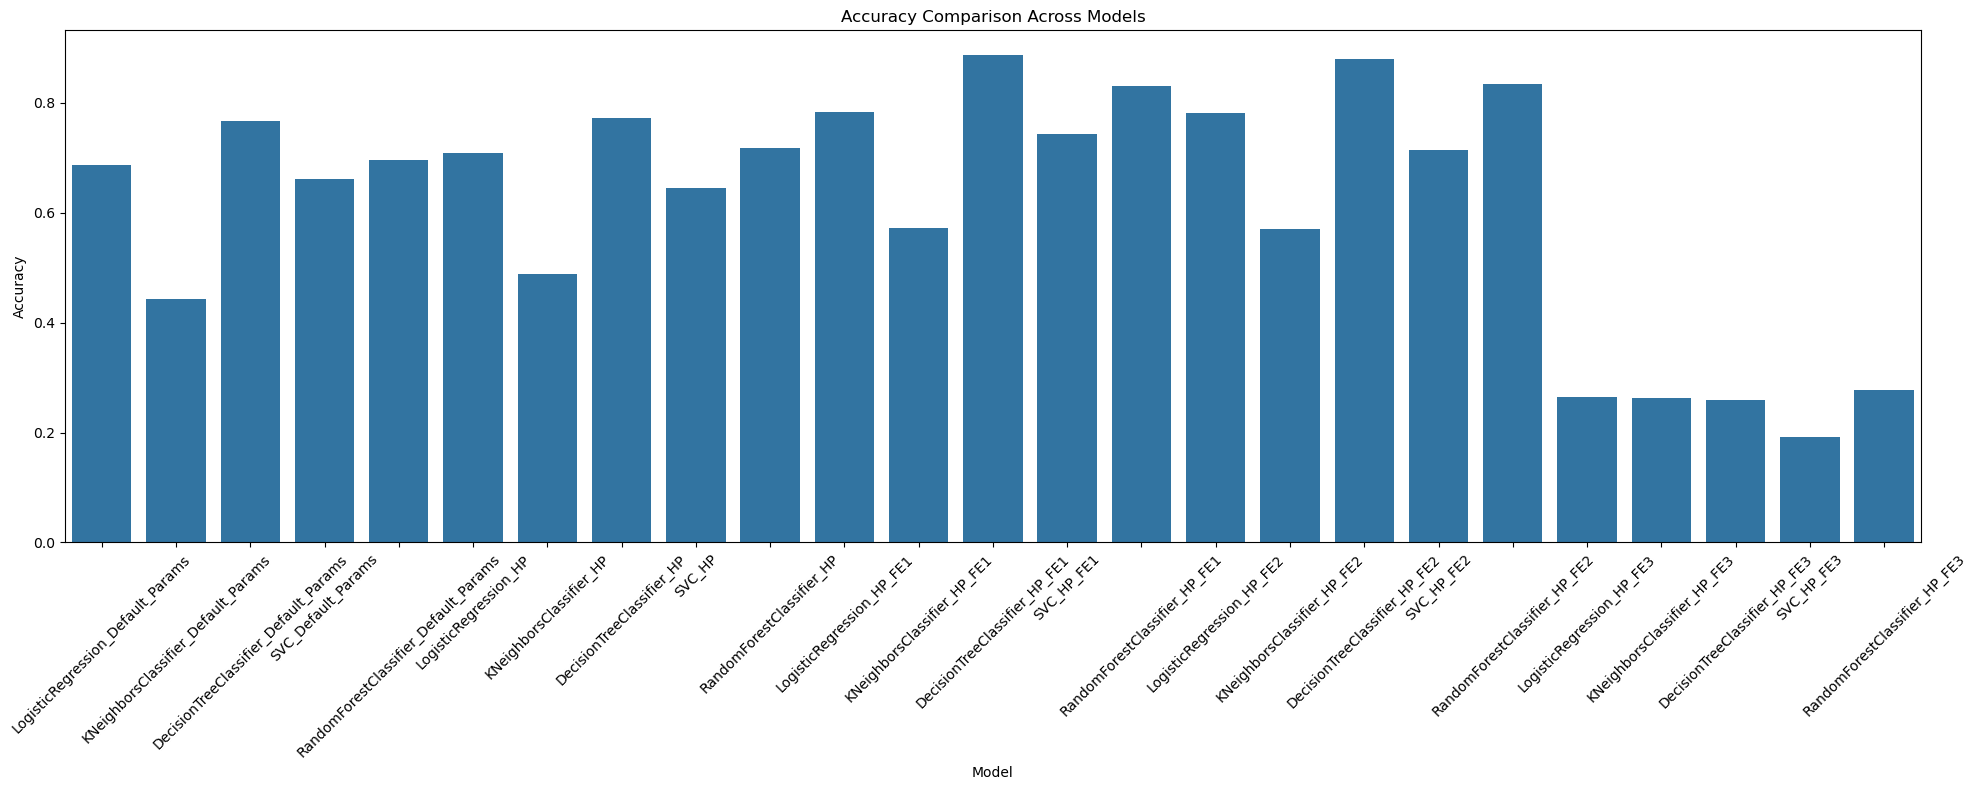

In [305]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(20,8))

sns.barplot(
    data=comb_results,
    x="Model",
    y="Accuracy"
)

plt.xticks(rotation=45)
plt.title("Accuracy Comparison Across Models")
plt.tight_layout()
plt.show()

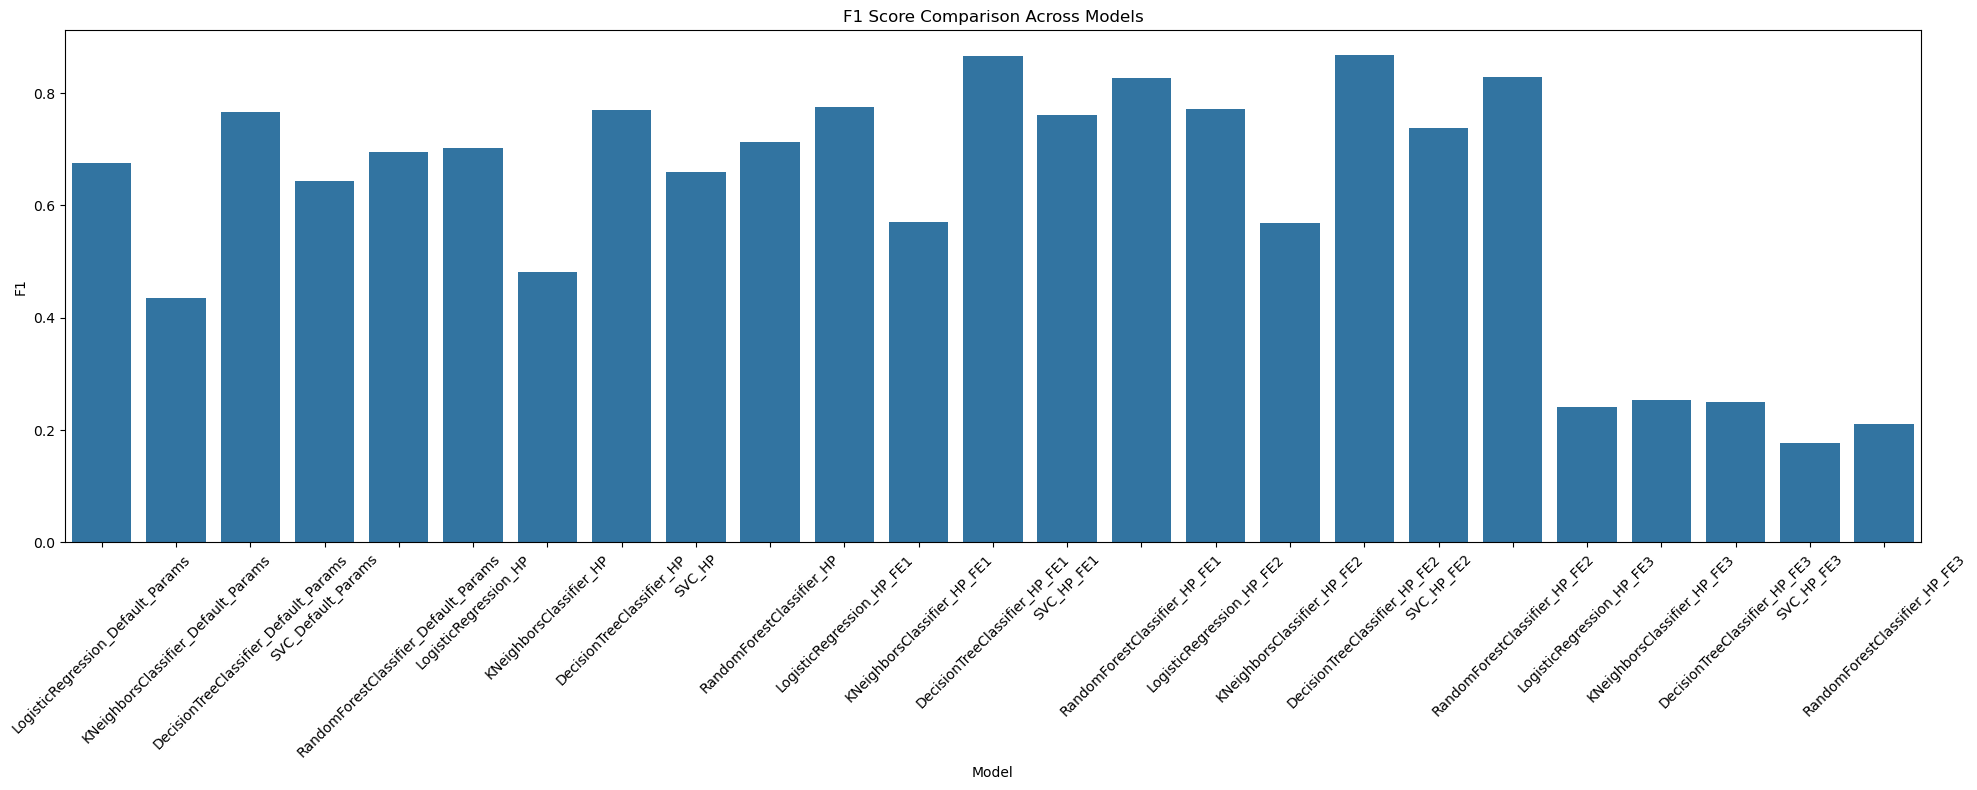

In [306]:
plt.figure(figsize=(20,8))

sns.barplot(
    data=comb_results,
    x="Model",
    y="F1"
)

plt.xticks(rotation=45)
plt.title("F1 Score Comparison Across Models")
plt.tight_layout()
plt.show()

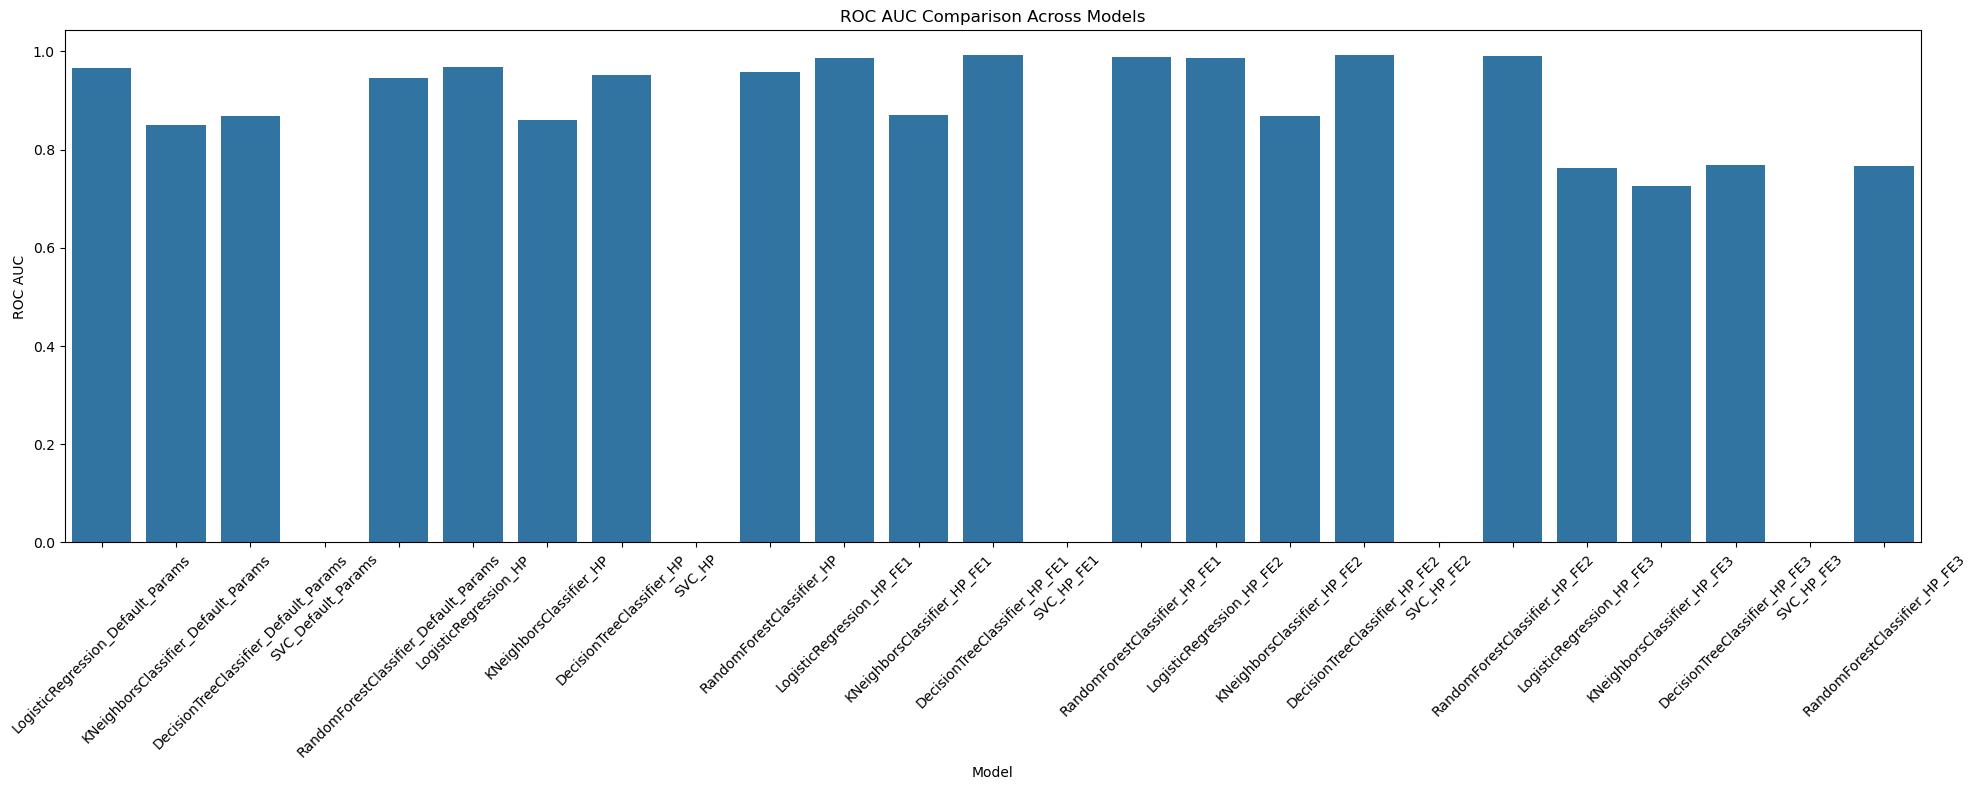

In [307]:
# ROC AUC Comparison Across Models
plt.figure(figsize=(20,8))

sns.barplot(
    data=comb_results,
    x="Model",
    y="ROC AUC"
)

plt.xticks(rotation=45)
plt.title("ROC AUC Comparison Across Models")
plt.tight_layout()
plt.show()

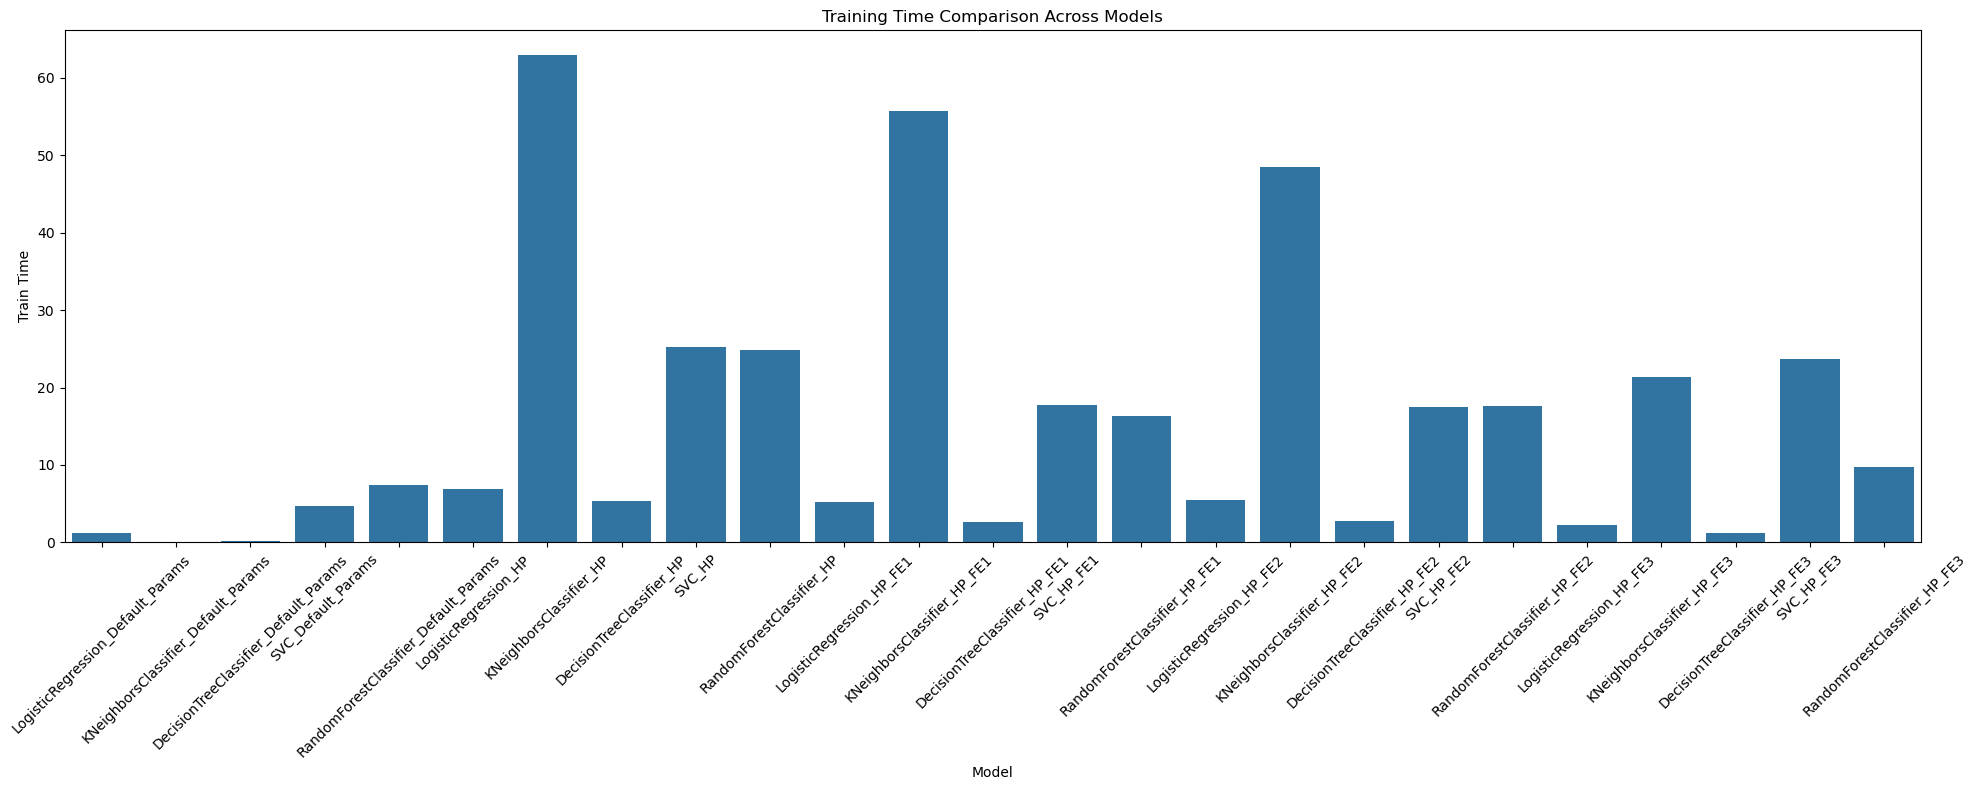

In [308]:
# Training Time Comparison Across Models
plt.figure(figsize=(20,8))

sns.barplot(
    data=comb_results,
    x="Model",
    y="Train Time"
)

plt.xticks(rotation=45)
plt.title("Training Time Comparison Across Models")
plt.tight_layout()
plt.show()

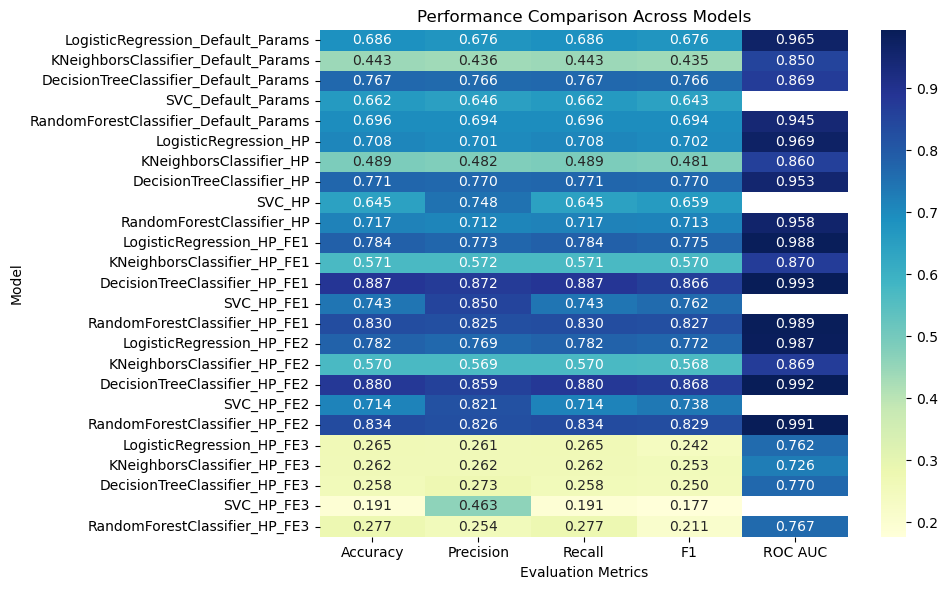

In [309]:
metrics = ["Accuracy", "Precision", "Recall", "F1", "ROC AUC"]

heatmap_df = comb_results.set_index("Model")[metrics]

plt.figure(figsize=(10,6))

sns.heatmap(
    heatmap_df,
    annot=True,
    cmap="YlGnBu",
    fmt=".3f"
)

plt.title("Performance Comparison Across Models")
plt.ylabel("Model")
plt.xlabel("Evaluation Metrics")
plt.tight_layout()
plt.show()

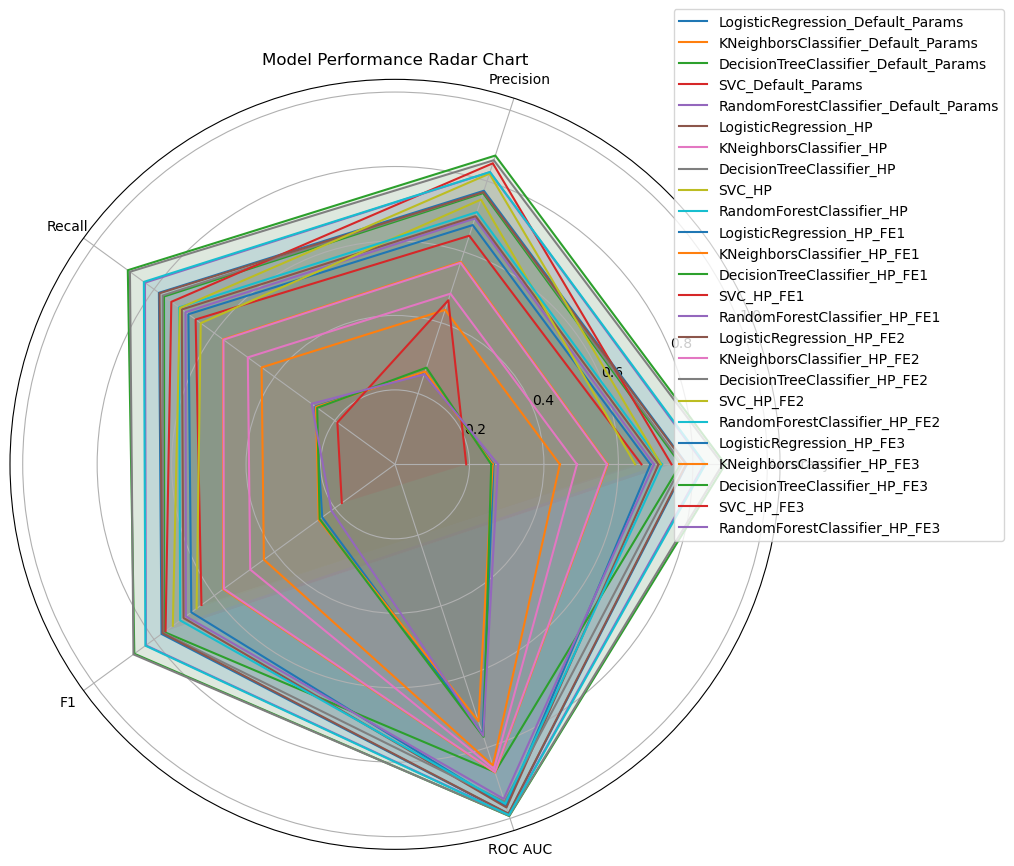

In [310]:
metrics = ["Accuracy","Precision","Recall","F1","ROC AUC"]

data = comb_results.set_index("Model")[metrics]

labels = np.array(metrics)
angles = np.linspace(0, 2*np.pi, len(labels), endpoint=False)

fig = plt.figure(figsize=(10,10))
ax = fig.add_subplot(111, polar=True)

for model in data.index:
    values = data.loc[model].values
    values = np.concatenate((values,[values[0]]))
    ang = np.concatenate((angles,[angles[0]]))
    
    ax.plot(ang, values, label=model)
    ax.fill(ang, values, alpha=0.1)

ax.set_thetagrids(angles * 180/np.pi, labels)
plt.title("Model Performance Radar Chart")
plt.legend(loc="upper right", bbox_to_anchor=(1.3,1.1))
plt.show()

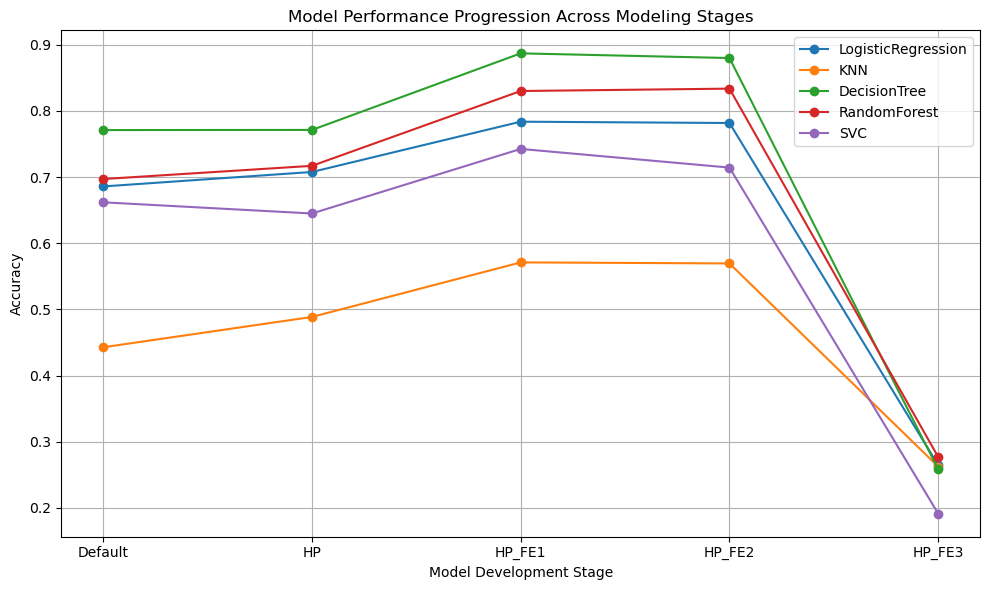

In [311]:
progression_df = pd.DataFrame({
    "Stage": ["Default", "HP", "HP_FE1", "HP_FE2", "HP_FE3"],
    "LogisticRegression": [0.685956, 0.707814, 0.783844, 0.781837, 0.264520],
    "KNN": [0.442872, 0.488701, 0.571172, 0.569588, 0.262408],
    "DecisionTree": [0.771172, 0.771383, 0.887117, 0.880042, 0.258395],
    "RandomForest": [0.697149, 0.717107, 0.830201, 0.833791, 0.276874],
    "SVC": [0.661985, 0.645090, 0.742661, 0.714467, 0.191341]
})

plt.figure(figsize=(10,6))

for model in progression_df.columns[1:]:
    plt.plot(
        progression_df["Stage"],
        progression_df[model],
        marker="o",
        label=model
    )

plt.title("Model Performance Progression Across Modeling Stages")
plt.xlabel("Model Development Stage")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## Model Comparison Across Experiments (Default → HP → FE1 → FE2 → FE3)

### Logistic Regression
* Shows consistent and stable performance across all experiments.
* Noticeable improvement with feature engineering (FE1/FE2), especially in accuracy and F1.
* Maintains strong ROC AUC throughout, indicating good class separability.
* Best suited as a baseline, interpretable model, but not the top performer.

### K-Nearest Neighbors (KNN)
* Weakest performer across all experiments.
* Slight improvement with hyperparameter tuning and feature engineering, but still significantly below others.
* High prediction time and sensitivity to feature scaling/geography.
* Not recommended for this dataset.

### Decision Tree
* Top performer across all experiments, especially after defining Hyperparameters and Feature Engineering.
* Achieves highest accuracy, precision, recall, F1 and ROC AUC consistently with Hyperparameters and Feature Engineering.
* Very fast training and prediction times.
* Risk of overfitting exists but controlled with tuning (max_depth, splits).

### Support Vector Classifier (SVC)
* Moderate performance across all stages.
* Benefits from feature engineering but still lags behind tree-based models.
* Higher training and prediction time.
* ROC-AUC was not computed for the SVC model because probability estimates were not enabled, and enabling them would significantly increase computational cost.
* Not optimal overall.

### Random Forest
* Consistently strong and reliable performer.
* Significant improvement after Feature Engineering (FE1/FE2).
* High ROC AUC and balanced precision–recall, indicating robustness.
* Slightly slower than Decision Tree but more stable (less overfitting).

### Real World Execution

Based on the comparative evaluation across all models and experiments, both the Decision Tree classifier and Random Forest Classifier with Hyperparameter Tuning and Feature Engineering 1 (HP_FE1) are most effective models. These models consistently achieved high accuracy, precision, recall, and F1 score, indicating strong predictive performance and balanced classification across all target classes. Additionally, they also delivered a high ROC AUC score, demonstrating excellent capability in distinguishing between crop classes.

Since both Decision Tree and Random Forest demonstrated strong and comparable performance across evaluation metrics, it is important to assess their behavior in real-world scenarios. Running sample-based predictions allows us to evaluate how each model performs in practical use, particularly in terms of recommendation quality and probability distribution. These results can then be used to select the most suitable model for deployment.


In [312]:

# This function generates top 3 crop recommendations using a trained model by accepting State and County as inputs, 
# aligning with real-world usage where limited information is available. It dynamically constructs the required features by 
# incorporating the latest year, handling missing counties, and deriving aggregated state and county yield values 
# from historical data to approximate model inputs.

def predict_top3_from_location(model, state, county):

    # label encoder
    label_encoder = lab_enc

    # Normalize input (important)
    state = state.upper()
    county = county.upper()

    # Reference values
    latest_year = crop_df_clean["Year"].max()

    # County missing flag
    county_missing_flag = 0 if county in crop_df_clean["County"].values else 1
    
    # State average
    state_rows = crop_df_clean[crop_df_clean["State"] == state]
    if not state_rows.empty:
        state_avg = state_rows["state_crop_avg_yield"].iloc[0]
    else:
        state_avg = crop_df_clean["state_crop_avg_yield"].mean()

    # County average
    county_rows = crop_df_clean[crop_df_clean["County"] == county]
    if not county_rows.empty:
        county_avg = county_rows["county_avg_yield"].iloc[0]
    else:
        county_avg = crop_df_clean["county_avg_yield"].mean()

    X_input = pd.DataFrame([{
        "State": state,
        "County": county,
        "Year": latest_year,
        "county_missing_flag": county_missing_flag,
        "state_crop_avg_yield": state_avg,
        "county_avg_yield": county_avg
    }])

    # Predict probabilities
    probs = model.predict_proba(X_input)[0]
    classes = model.classes_

    # Get Top 3
    top_idx = np.argsort(probs)[::-1][:3]

    results = []
    for rank, i in enumerate(top_idx, start=1):
        label = classes[i]

        if label_encoder is not None:
            label = label_encoder.inverse_transform([label])[0]

        results.append({
            "Rank": rank,
            "Crop": label,
            "Probability": round(probs[i], 4)
        })

    return pd.DataFrame(results)

In [313]:
#  Real world evaluation of Decision Tree and Random Forest classifier models with Hyper Parameters and Feature Engineering 1 (HP_FE1)

X_train, X_test, y_train, y_test = train_test_split(
    X_FE1,
    y_encoded,
    test_size=0.30,
    random_state=42,
    stratify=y_encoded
)

preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_feats_FE1),
        ("num", StandardScaler(), num_feats_FE1)
    ]
)


dt_pipe = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", DecisionTreeClassifier(random_state=42))
])

dt_param_grid = {
    "model__max_depth": [10],
    "model__min_samples_split": [20],
    "model__min_samples_leaf": [5],
    "model__criterion": ["entropy"],
    "model__class_weight": [None]
} 

dt_grid = GridSearchCV(
    dt_pipe,
    dt_param_grid,
    scoring="accuracy",
    cv=5,
    n_jobs=-1
)

rf_pipe = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", RandomForestClassifier(random_state=42, n_jobs=-1))
    ])

rf_param_grid = {
        "model__n_estimators": [200],
        "model__max_depth": [None],
        "model__min_samples_split": [2],
        "model__min_samples_leaf": [1]
    } 
    
rf_grid = GridSearchCV(
    rf_pipe,
    rf_param_grid,
    scoring="accuracy",
    cv=5,
    n_jobs=-1
)


rf_grid.fit(X_train, y_train)
best_rf_model = rf_grid.best_estimator_

dt_grid.fit(X_train, y_train)
best_dt_model = dt_grid.best_estimator_


In [314]:
# Side by side results of both Decision Tree vs Random Forest Classifiers with HP_FE1
samples = [
    ("TEXAS", "BELL"),
    ("WYOMING", "PARK"),
    ("ILLINOIS", "CHAMPAIGN")
]

results = []

for state, county in samples:

    dt_preds = predict_top3_from_location(best_dt_model, state, county)
    rf_preds = predict_top3_from_location(best_rf_model, state, county)
    
    for i in range(3):
        results.append({
            "State": state,
            "County": county,
            "Rank": i+1,
            
            "DT_Crop": dt_preds.iloc[i]["Crop"],
            "DT_Prob": dt_preds.iloc[i]["Probability"],
            
            "RF_Crop": rf_preds.iloc[i]["Crop"],
            "RF_Prob": rf_preds.iloc[i]["Probability"]
        })

comparison_df = pd.DataFrame(results)
comparison_df_disp = comparison_df.style.set_table_styles([
    {'selector': '', 'props': [('border', '1px solid black')]},
    {'selector': 'td', 'props': [('border', '1px solid black')]},
    {'selector': 'th', 'props': [('border', '1px solid black')]}
])
comparison_df_disp

,State,County,Rank,DT_Crop,DT_Prob,RF_Crop,RF_Prob
0,TEXAS,BELL,1,CORN_GRAIN,1.000000,CORN_GRAIN,0.915000
1,TEXAS,BELL,2,WHEAT_WINTER,0.000000,COTTON_UPLAND,0.070000
2,TEXAS,BELL,3,"WHEAT_SPRING, (EXCL DURUM)",0.000000,SORGHUM_GRAIN,0.015000
3,WYOMING,PARK,1,BARLEY_BARLEY,1.000000,BARLEY_BARLEY,0.850000
4,WYOMING,PARK,2,"WHEAT_SPRING, (EXCL DURUM)",0.000000,SOYBEANS_SOYBEANS,0.080000
5,WYOMING,PARK,3,"BEANS_DRY EDIBLE, INCL CHICKPEAS",0.000000,COTTON_UPLAND,0.050000
6,ILLINOIS,CHAMPAIGN,1,HAY_(EXCL ALFALFA),0.638700,SORGHUM_GRAIN,0.190000
7,ILLINOIS,CHAMPAIGN,2,HAY_ALFALFA,0.361300,WHEAT_WINTER,0.172500
8,ILLINOIS,CHAMPAIGN,3,WHEAT_WINTER,0.000000,CORN_GRAIN,0.137900


## Overall Conclusion – Decision Tree vs Random Forest
* The Decision Tree model produces highly confident but rigid predictions, often assigning extreme probabilities (0 or 1), which leads to limited diversity in recommendations beyond the top rank.
* In contrast, the Random Forest model generates more balanced probability distributions, resulting in more meaningful and diverse Top-3 crop recommendations.
* Across multiple locations, both models generally agree on the top-ranked crop, indicating consistency in identifying dominant regional crops.
* Random Forest provides better differentiation in lower-ranked predictions, capturing alternative crop options that the Decision Tree fails to represent.

Overall, while Decision Tree is simpler and highly interpretable, Random Forest is better suited for recommendation systems, as it offers improved generalization and more reliable probability-based rankings.

## Deployment Report

### Overview
The deployment focuses on operationalizing the trained machine learning model to provide real-time crop recommendations based on user inputs. The final solution is designed to accept State and County as inputs and return the Top-3 recommended crops with probabilities, enabling practical use by farmers, agricultural stakeholders, and lenders

### Final Model Selection
After evaluating multiple models across different feature engineering strategies, Random Forest was selected as the final model for deployment. While Decision Tree showed comparable accuracy, Random Forest demonstrated better generalization and produced more reliable and diverse probability-based recommendations during real-world sample testing.

### System Architectural Components
* Trained Random Forest model (**best_rf_model**)
* Prediction function for Top-3 recommendations (predict_top3_from_location)


#### Input and Output Design

* **Inputs:**
    * State (Example: TENNESSEE)
    * County (Example: LINCOLN)

* **Output:**
    * Top 3 recommended crops
    * Associated probability scores

**Example**
Below with sample code and results


In [315]:
state = "TENNESSEE"
county = "LINCOLN"
preds = predict_top3_from_location(best_rf_model, state, county)
preds_df = pd.DataFrame(preds)
preds_disp = preds_df.style.set_table_styles([
    {'selector': '', 'props': [('border', '1px solid black')]},
    {'selector': 'td', 'props': [('border', '1px solid black')]},
    {'selector': 'th', 'props': [('border', '1px solid black')]}
])
preds_disp

,Rank,Crop,Probability
0,1,CORN_GRAIN,0.865000
1,2,COTTON_UPLAND,0.095000
2,3,WHEAT_WINTER,0.025000


#### Deployment Approach:
* **The model can be deployed using the following approaches**
    * **UI Integration and API-Based Deployment:** Deploy the model as an API  using frameworks like FastAPI and integrate it with a web or mobile interface to enable farmers and stakeholders to access crop recommendations in real time.
    * **Batch Deployment:** Generate recommendations for multiple regions periodically.

#### Limitations
* Predictions are based on geographical features and yield only and deosn't include real-time environmental factors like weather and soil conditions
* Model performance may vary on sparse data

#### Future Enhancements
* Integrate weather and soil data for improved predictions
* Build a user friendly dashboard
* Add explainability features to improve transparency

### Summary
The deployed solution provides a practical crop recommendation system that balances model performance with real-world usability, enabling data-driven agricultural decision-making.

# Executive Summary

This project presents a machine learning crop prediction and recommendation system designed to support farmers, agricultural stakeholders, and lenders in making informed data-driven decisions. By leveraging historical agricultural data at the state and county level, multiple models including Logistic Regression, KNN, Decision Tree, SVC and Random Forest were developed and evaluated using various feature engineering strategies to identify the most effective approach.

Introducing only State and County as input features resulted in low model accuracy, highlighting the limited predictive power of geographic data alone. Incorporating yield-based features significantly improved accuracy, but also introduced practical constraints. While the Decision Tree model achieved slightly higher accuracy, it produced overly confident and rigid predictions with limited variability in alternative recommendations. In contrast, Random Forest provided better differentiation across lower-ranked predictions, offering more diverse and realistic crop options. Based on comparative analysis and real-world sample testing, Random Forest was selected as the preferred model as it strikes a better balance between predictive performance and practical usability for crop recommendation.

The final system enables users to input a state and county and receive ranked crop recommendations, supporting better crop selection, reducing agricultural risk and aiding lenders in risk assessment. Overall, the project highlights the importance of feature design, model selection and aligning machine learning solutions with real-world usability.
